<a href="https://colab.research.google.com/github/Muse-M/FinalYearProject/blob/main/Testing_Theories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing theories on results obtained from QSO + Many Gal + Noise


---

- What do results look like if the model is trained on data exculding red galaxies?
    
    - what about reducing the numebr of red galaxies with high dn4000 and then over sample the other red galaxies left to come up to the 2000 galaxies mark- only over sample in train set

        - Removing red actually makes prediction in green for Dn4000 a lot worse.Might be due to generally having less data. Need to look into removing the high dn400 values and oversampling the remaing.
    
            - But the fgal cmap graph show that low fgal fraction (i.e spectra is just agn) is the reason the predictions in dn4000 for red galaxies is bad, not the fact they are red galaxies. **is oversampling the answer**

            - should i only be oversampling the training dataset and not touching the validation

    - what about excluding SB galaxies?
    
        - No, there is good reason for potentially not including red gals which is due to the dataset creation and Dn4000 values. The case for SB galaxies cant;t be made and the reason they dont predict as well is due to OB star - AGN link, an actual physical reason

    
- Is generalisation really the reason why simultaneous training performes better?
    - Test this by assigning a different number in the new channel:
        - Yes, even when the intial f-gal model is better, the random number model version performs worse


- Go back to guided grad cam and see if the highlighted lines make sense- like the way Al lines showed up before
    - Re read the way sanity checks in saliency map paper makes sure the guided grad cam and grad cam are working and model dependent

- Would prediciting gal type improve accuracy?


## Imports

In [1]:
# Pytorch imports
import torch
import torch.utils.data as data
import torch.nn as nn
#from torch.utils.tensorboard import SummaryWriter

# import captum
# from captum.attr import (
#     GradientShap,
#     DeepLift,
#     DeepLiftShap,
#     IntegratedGradients,
#     LayerConductance,
#     NeuronConductance,
#     NoiseTunnel)

# General Python imports
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif" # Standardise font throughout whole notebook
from   matplotlib.ticker import AutoMinorLocator
import seaborn as sns
import numpy as np
import os
import pandas as pd
import pickle
from datetime import datetime
import joblib

# Quality of life imports
from tqdm.notebook import tqdm # progress Bar
from accelerate import Accelerator

# data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import r2_score

# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter
# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
%load_ext tensorboard

In [2]:
################UoA code################
torch.manual_seed(42) # Setting the seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device cuda


## data load

In [3]:
dataPath='/content/drive/MyDrive/many qso + many gal + noise 2'
filePaths=[]
for i in os.listdir(dataPath):
  filePaths.append(os.path.join(dataPath, i))


In [4]:
from functools import total_ordering
from concurrent.futures import ThreadPoolExecutor

def load_pickle(file_path ):
    a=filePaths.index(file_path)
    if a%1000==0:
        print(str(a)+'/10000')
    with open(file_path, "rb") as f:
        try:
            data = pickle.load(f)
            data['wl'] = data['wl'].flatten()
            df=pd.DataFrame(data)
            df_single_row = pd.DataFrame({col: [df[col].tolist()] for col in df.columns})
            return df_single_row
        except Exception as e:
            print(f"Error loading file: {file_path[len(dataPath):]} | {e}")

# Load files in parallel
# Loads each pickle file from drive as a dataframe with 1 row and adds to list dataframes
with ThreadPoolExecutor() as executor:
    dataframes = list(executor.map(load_pickle, filePaths))



# concatenate all dataframes into 1 dataframe
final_df = pd.concat(dataframes, ignore_index=True)
final_df.shape

0/10000
1000/10000
2000/10000
3000/10000
4000/10000
5000/10000
6000/10000
7000/10000
8000/10000
9000/10000


(10000, 9)

In [5]:
final_df.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...","[red, red, red, red, red, red, red, red, red, ...","[0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.2...","[1.9055955462768537, 1.9055955462768537, 1.905...","[-1.466245245968707, -1.466245245968707, -1.46..."
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...","[red, red, red, red, red, red, red, red, red, ...","[0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.7...","[1.8962762902563093, 1.8962762902563093, 1.896...","[-1.5121581382752982, -1.5121581382752982, -1...."
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...","[red, red, red, red, red, red, red, red, red, ...","[0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.8...","[1.9228175140027075, 1.9228175140027075, 1.922...","[-1.2747974793001169, -1.2747974793001169, -1...."
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...","[red, red, red, red, red, red, red, red, red, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[1.81027654592034, 1.81027654592034, 1.8102765...","[-0.8497407749135834, -0.8497407749135834, -0...."
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...","[red, red, red, red, red, red, red, red, red, ...","[0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.7...","[1.9166287600600451, 1.9166287600600451, 1.916...","[-1.532779964391233, -1.532779964391233, -1.53..."


In [6]:
firstDataset=final_df.copy(deep=True)
# converts columns that should be single valued into single values i.e [0.01,0.01,0.01....] => 0.01
firstDataset['f_gal'] = firstDataset['f_gal'].apply(lambda x: x[0])
firstDataset['gal_type'] = firstDataset['gal_type'].apply(lambda x: x[0])
firstDataset['dn4000'] = firstDataset['dn4000'].apply(lambda x: x[0])
firstDataset['hdelta'] = firstDataset['hdelta'].apply(lambda x: x[0])


# transforms categorical gal_types into numeric
le = LabelEncoder()
firstDataset['gal_type_code'] = le.fit_transform(firstDataset['gal_type'])

In [7]:
firstDataset.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta,gal_type_code
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...",red,0.22,1.905596,-1.466245,4
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...",red,0.74,1.896276,-1.512158,4
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...",red,0.86,1.922818,-1.274797,4
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...",red,0.10,1.810277,-0.849741,4
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...",red,0.71,1.916629,-1.532780,4


<Axes: >

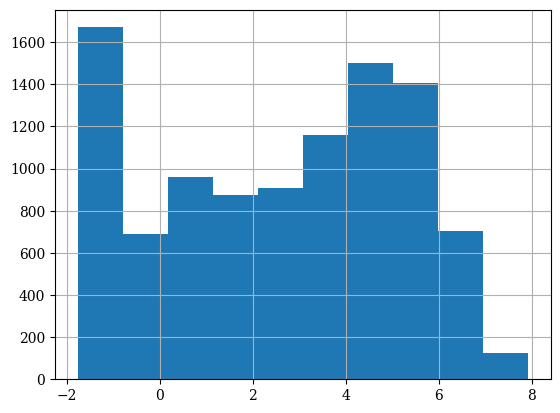

In [8]:
firstDataset['hdelta'].hist()

<Axes: >

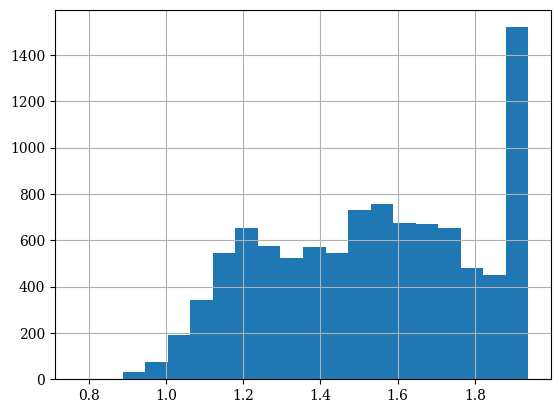

In [9]:
firstDataset['dn4000'].hist(bins=20)

(array([2.000e+00, 3.000e+00, 1.000e+00, 1.600e+01, 2.700e+01, 9.200e+01,
        1.680e+02, 2.960e+02, 4.640e+02, 5.990e+02, 5.620e+02, 6.020e+02,
        6.090e+02, 6.060e+02, 8.880e+02, 8.960e+02, 9.010e+02, 8.630e+02,
        6.640e+02, 1.741e+03]),
 array([-0.25939188, -0.21331436, -0.16723685, -0.12115933, -0.07508181,
        -0.0290043 ,  0.01707322,  0.06315074,  0.10922825,  0.15530577,
         0.20138329,  0.2474608 ,  0.29353832,  0.33961584,  0.38569335,
         0.43177087,  0.47784839,  0.5239259 ,  0.57000342,  0.61608094,
         0.66215845]),
 <BarContainer object of 20 artists>)

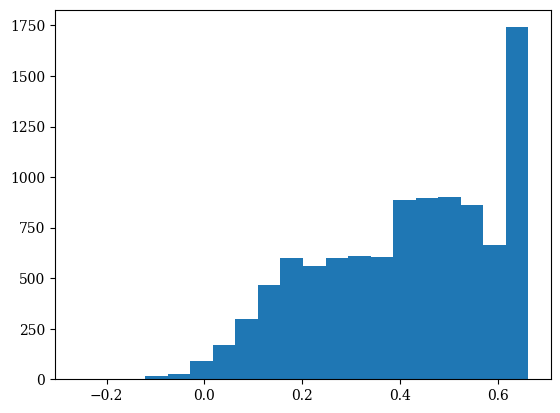

In [10]:
plt.hist(np.log(np.array(firstDataset['dn4000'])), bins=20)

SB: 2000
SF: 2000
green: 2000
red: 2000
PSB: 2000


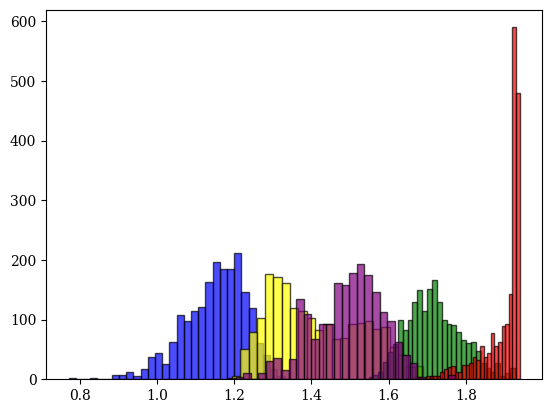

In [11]:
filtered_df = firstDataset[firstDataset['gal_type'] == 'SB']
plt.hist(filtered_df['dn4000'], bins=30, alpha=0.7, color='blue', edgecolor='black')
print('SB: '+ str(len(filtered_df)))

filtered_df = firstDataset[firstDataset['gal_type'] == 'SF']
plt.hist(filtered_df['dn4000'], bins=30, alpha=0.7, color='yellow', edgecolor='black')
print('SF: '+ str(len(filtered_df)))

filtered_df = firstDataset[firstDataset['gal_type'] == 'green']
plt.hist(filtered_df['dn4000'], bins=30, alpha=0.7, color='green', edgecolor='black')
print('green: '+ str(len(filtered_df)))

filtered_df = firstDataset[firstDataset['gal_type'] == 'red']
plt.hist(filtered_df['dn4000'], bins=30, alpha=0.7, color='red', edgecolor='black')
print('red: '+ str(len(filtered_df)))

filtered_df = firstDataset[firstDataset['gal_type'] == 'PSB']
plt.hist(filtered_df['dn4000'], bins=30, alpha=0.7, color='purple', edgecolor='black')

print('PSB: '+ str(len(filtered_df)))

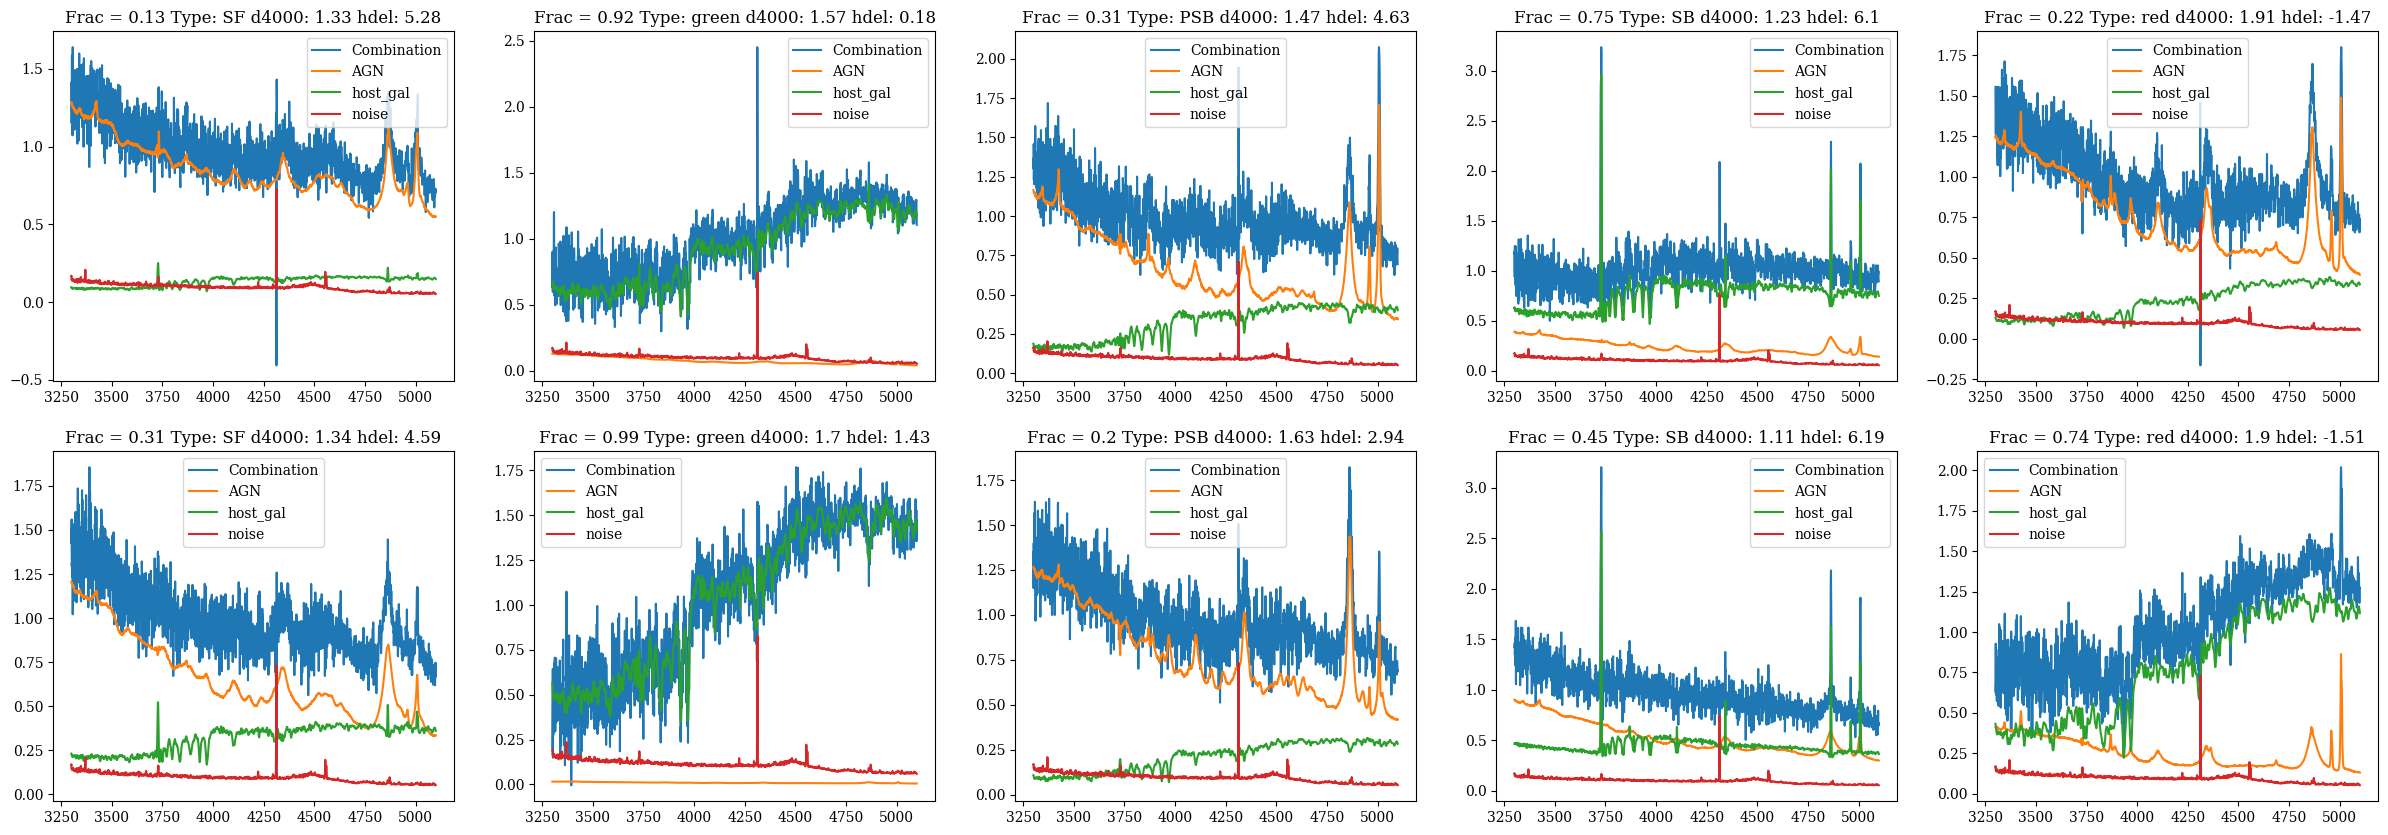

In [12]:
types= ['SF',  'green', 'PSB', 'SB', 'red']
fig, ax = plt.subplots(figsize=(30,10), ncols=5, nrows=2)
uniqueType=[]

i=0
graph=0

while len(uniqueType) < 10: # plot spectra if that gal_type is new
    singleRow=firstDataset.iloc[[i]]
    wl= singleRow['wl'].iloc[0]
    flux= singleRow['flux'].iloc[0]
    true_AGN= singleRow['true_AGN'].iloc[0]
    true_gal= singleRow['true_gal'].iloc[0]
    noise_array=singleRow['error'].iloc[0]
    gal_type=singleRow['gal_type'].iloc[0]
    f_gal= singleRow['f_gal'].iloc[0]
    d4000= singleRow['dn4000'].iloc[0]
    hdel= singleRow['hdelta'].iloc[0]

    i+=1

    typecount=uniqueType.count(gal_type)

    if typecount>=2:
        pass
    else:
        ax[typecount,types.index(gal_type)].plot(wl, flux, label='Combination')
        ax[typecount,types.index(gal_type)].plot(wl, true_AGN, label='AGN')
        ax[typecount,types.index(gal_type)].plot(wl, true_gal, label='host_gal')
        ax[typecount,types.index(gal_type)].plot(wl, noise_array, label='noise')
        ax[typecount,types.index(gal_type)].set_title('Frac = '+str(f_gal)+ ' Type: '+ gal_type + ' d4000: ' +str(round(d4000,2)) + ' hdel: ' + str(round(hdel,2)))
        ax[typecount,types.index(gal_type)].legend()
        if typecount==1:
            graph+=1
        uniqueType.append(gal_type)




## ResNet50 Model

### Class

In [13]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)

        if self.downsample:
            x=self.downsampleConv(x)

        h=f+x
        return self.act(h)



class fullResNetModel50(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride, chainNumber, **kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride
        self.chainNumber=chainNumber

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

                self.outputLayerAvgPool=nn.AdaptiveAvgPool1d(1)
                self.outputflattenLayer=nn.Flatten()
                self.outputFC=nn.Linear(self.channelList[-1]+self.chainNumber, self.classes)




    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, previousPredictions=None):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayerAvgPool(x) # 1 value per channel
        x=self.outputflattenLayer(x) # flatten to 1 dim

        if previousPredictions != None:
            x=torch.cat((x,previousPredictions), dim=1) # concat the predictions from earlier models

        x=self.outputFC(x)
        return x


## Train Loop

In [14]:
# train 3 models at the same time
def regressorTrainLoop(model, batch_data, batch_label,lossCalculator, optimiser):

    model.train()

    prediction=model(batch_data).squeeze()
    loss= lossCalculator(prediction, batch_label)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss = loss.item() # per batch

    return epoch_train_loss, prediction


def regressorValidationLoop(model, batch_data, batch_label,lossCalculator ):
    model.eval()
    with torch.no_grad():
        prediction=model(batch_data).squeeze()
        lossValue=lossCalculator(prediction, batch_label).item()


    return lossValue, prediction

def epochLoop(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    M3_fgal_trainLossCurve=[]
    M3_fgal_validLossCurve=[]
    M3_dn4_trainLossCurve=[]
    M3_dn4_validLossCurve=[]
    M3_hdelta_trainLossCurve=[]
    M3_hdelta_validLossCurve=[]

    classdiffVSepoch_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_hdelta=[[],[],[],[],[],[]]

    classdiffVSepoch_valid_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_hdelta=[[],[],[],[],[],[]]

    allClass=[classdiffVSepoch_fgal, classdiffVSepoch_dn4, classdiffVSepoch_hdelta, classdiffVSepoch_valid_fgal, classdiffVSepoch_valid_dn4, classdiffVSepoch_valid_hdelta]

    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0

        allPredictionDiffs_fgal=np.array([[],[]])
        allPredictionDiffs_dn4=np.array([[],[]])
        allPredictionDiffs_hdelta=np.array([[],[]])

        allPredictionDiffs_valid_fgal=np.array([[],[]])
        allPredictionDiffs_valid_dn4=np.array([[],[]])
        allPredictionDiffs_valid_hdelta=np.array([[],[]])

        for batch_flux, batch_f_gal, batch_hue , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal)

            allPredictionDiffs_fgal=[np.append(allPredictionDiffs_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_fgal[1]]
            allPredictionDiffs_fgal=[allPredictionDiffs_fgal[0],np.append(allPredictionDiffs_fgal[1], batch_hue.cpu().numpy())]


            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4)
            allPredictionDiffs_dn4=[np.append(allPredictionDiffs_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_dn4[1]]
            allPredictionDiffs_dn4=[allPredictionDiffs_dn4[0],np.append(allPredictionDiffs_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdeltaPrediction = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            predictionDiff=abs(hdeltaPrediction - batch_hdel)
            allPredictionDiffs_hdelta=[np.append(allPredictionDiffs_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_hdelta[1]]
            allPredictionDiffs_hdelta=[allPredictionDiffs_hdelta[0],np.append(allPredictionDiffs_hdelta[1], batch_hue.cpu().numpy())]

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, batch_hue , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal_V)
            allPredictionDiffs_valid_fgal=[np.append(allPredictionDiffs_valid_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_fgal[1]]
            allPredictionDiffs_valid_fgal=[allPredictionDiffs_valid_fgal[0],np.append(allPredictionDiffs_valid_fgal[1], batch_hue.cpu().numpy())]

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4_V)
            allPredictionDiffs_valid_dn4=[np.append(allPredictionDiffs_valid_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_dn4[1]]
            allPredictionDiffs_valid_dn4=[allPredictionDiffs_valid_dn4[0],np.append(allPredictionDiffs_valid_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdelPrediction = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            predictionDiff=abs(hdelPrediction - batch_hdel_V)
            allPredictionDiffs_valid_hdelta=[np.append(allPredictionDiffs_valid_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_hdelta[1]]
            allPredictionDiffs_valid_hdelta=[allPredictionDiffs_valid_hdelta[0],np.append(allPredictionDiffs_valid_hdelta[1], batch_hue.cpu().numpy())]

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3


        allPredictionDiffs=[allPredictionDiffs_fgal, allPredictionDiffs_dn4,allPredictionDiffs_hdelta,allPredictionDiffs_valid_fgal,allPredictionDiffs_valid_dn4,allPredictionDiffs_valid_hdelta]

        index=0
        for i in allPredictionDiffs:
            class0idx=np.where(i[1] == 0)[0]
            class1idx=np.where(i[1] == 1)[0]
            class2idx=np.where(i[1] == 2)[0]
            class3idx=np.where(i[1] == 3)[0]
            class4idx=np.where(i[1] == 4)[0]

            allClass[index]=[np.append(allClass[index][0],np.sum(i[0][class0idx])/len(class0idx)),allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],np.append(allClass[index][1],np.sum(i[0][class1idx])/len(class1idx)),allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],np.append(allClass[index][2],np.sum(i[0][class2idx])/len(class2idx)),allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],np.append(allClass[index][3],np.sum(i[0][class3idx])/len(class3idx)),allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],np.append(allClass[index][4],np.sum(i[0][class4idx])/len(class4idx)),allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],np.append(allClass[index][5],np.sum(i[0])/len(i[0]))]

            index+=1


        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        M3_fgal_trainLossCurve.append(epoch_train_loss_F_gal)
        M3_fgal_validLossCurve.append(epoch_valid_loss_F_gal)
        M3_dn4_trainLossCurve.append(epoch_train_loss_dn4)
        M3_dn4_validLossCurve.append(epoch_valid_loss_dn4)
        M3_hdelta_trainLossCurve.append(epoch_train_loss_hdel)
        M3_hdelta_validLossCurve.append(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal, 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal, 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4, 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4, 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel, 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel, 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])


    return M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, allClass

## graphing functions




In [15]:
from ast import Index
#graph
def dataFor_graphPredictionTruth(model, train_data_loader, valid_data_loder, dataLoaderLen, cmapFeature ,predictingWhat=None):
    # returns model predictions on training and validation data
    model.eval()
    predict_train=np.array([])
    truth_train=np.array([])
    diff_train=np.array([])
    hue_train=np.array([])

    predict_val=np.array([])
    truth_val=np.array([])
    diff_val=np.array([])
    hue_val=np.array([])

    if predictingWhat != None:
        for flux, f_gal, dn4000, hdelta, gal_type_code in train_data_loader:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code

                if predictingWhat == 'f-gal':
                    trial_batch_t=f_gal.to(device)
                elif  predictingWhat == 'dn4000' :
                    trial_batch_t=dn4000.to(device)
                elif predictingWhat == 'hdelta':
                    trial_batch_t=hdelta.to(device)


                try:
                    if trial_batch_p.shape[1] not in [1,2,3]:
                        trial_batch_p=trial_batch_p.unsqueeze(1)
                except IndexError:
                    if trial_batch_p.shape[0] not in [1,2,3]:
                        trial_batch_p=trial_batch_p.unsqueeze(0).unsqueeze(1)



                predict_train=np.append(predict_train, model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())

            if cmapFeature == 'gal_type':
                hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())
            elif cmapFeature == 'f-gal':
                hue_train=np.append(hue_train, f_gal.cpu().detach().numpy())
            else:
                hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

        diff_train=np.append(diff_train,truth_train-predict_train)


        for flux, f_gal, dn4000, hdelta, gal_type_code in valid_data_loder:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code

                if predictingWhat == 'f-gal':
                    trial_batch_t=f_gal.to(device)
                elif  predictingWhat == 'dn4000' :
                    trial_batch_t=dn4000.to(device)
                elif predictingWhat == 'hdelta':
                    trial_batch_t=hdelta.to(device)

                try:
                    if trial_batch_p.shape[1] not in [1,2,3]:
                        trial_batch_p=trial_batch_p.unsqueeze(1)
                except IndexError:
                    if trial_batch_p.shape[0] not in [1,2,3]:
                        trial_batch_p=trial_batch_p.unsqueeze(0).unsqueeze(1)

                predict_val=np.append(predict_val,model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())

            if cmapFeature == 'gal_type':
                hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())
            elif cmapFeature == 'f-gal':
                hue_val=np.append(hue_val, f_gal.cpu().detach().numpy())
            else:
                hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

        diff_val=truth_val-predict_val
    elif predictingWhat == None and dataLoaderLen == 3:
        for flux, label, gal_type_code in train_data_loader:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code
                trial_batch_t=label.to(device)

                if trial_batch_p.shape[1] not in [1,2,3]:
                    trial_batch_p=trial_batch_p.unsqueeze(1)

                predict_train=np.append(predict_train, model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
            hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

        diff_train=np.append(diff_train,truth_train-predict_train)

        for flux, label, gal_type_code in valid_data_loder:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code
                trial_batch_t=label.to(device)

                if trial_batch_p.shape[1] not in [1,2,3]:
                    trial_batch_p=trial_batch_p.unsqueeze(1)

                predict_val=np.append(predict_val,model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
            hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

        diff_val=truth_val-predict_val


    elif predictingWhat == None and dataLoaderLen == 5:
        for flux, label, _,_ ,gal_type_code in train_data_loader:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code
                trial_batch_t=label.to(device)

                if trial_batch_p.shape[1] not in [1,2,3]:
                    trial_batch_p=trial_batch_p.unsqueeze(1)

                predict_train=np.append(predict_train, model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
            hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

        diff_train=np.append(diff_train,truth_train-predict_train)

        for flux, label,_,_ , gal_type_code in valid_data_loder:
            with torch.no_grad():
                trial_batch_p=flux.to(device)
                trial_batch_hue=gal_type_code
                trial_batch_t=label.to(device)

                if trial_batch_p.shape[1] not in [1,2,3]:
                    trial_batch_p=trial_batch_p.unsqueeze(1)

                predict_val=np.append(predict_val,model(trial_batch_p).cpu().squeeze().detach().numpy())
            truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
            hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

        diff_val=truth_val-predict_val



    return [predict_train,truth_train,diff_train, hue_train], [predict_val,truth_val,diff_val,hue_val]

In [16]:
def graphPredictionTruth(predict_train, truth_train, diff_train, hue_train,predict_val, truth_val, diff_val, hue_val, attempt,ax, hueBool, le):
    # uses prediction from dataFor_graphPredictionTruth_alex to plot graphs
    ax[0].set_yticklabels([])
    ax[0].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[1].set_xticklabels([])

    frame2=fig.add_axes((.05,.25,.45,.75)) # splits graphs into 4 graphs with bottom 2 graphs being smaller
    frame1=fig.add_axes((.05,.01,.45,.25))

    frame4=fig.add_axes((.54,.25,.45,.75))
    frame3=fig.add_axes((.54,.01,.45,.25))

    trainR2=r2_score(truth_train, predict_train)
    valR2=r2_score(truth_val, predict_val)

    r2X=max(truth_train)*0.75
    r2Y=min(predict_train)*1.05
    frame2.text(r2X,r2Y, r'$R^2=$ '+str(round(trainR2,3)), fontsize=20)
    r2X=max(truth_val)*0.75
    r2Y=min(predict_val)*1.05
    frame4.text(r2X,r2Y, r'$R^2=$ '+str(round(valR2,3)), fontsize=20)

    # r2X=min(truth_train)*1.05
    # r2Y=max(predict_train)*0.95
    # frame2.text(r2X,r2Y, r'$R^2=$ '+str(round(trainR2,3)), fontsize=20)
    # r2X=min(truth_val)*1.05
    # r2Y=max(predict_val)*0.95
    # frame4.text(r2X,r2Y, r'$R^2=$ '+str(round(valR2,3)), fontsize=20)

    # creates 2D array of training results and validation results
    t = np.array(list(zip(predict_train, truth_train, diff_train, hue_train)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])
    if hueBool == False:
        # doesn't colour based on gal_type
        frame2.scatter(x=t['truth'], y=t['predict'], c='blue', alpha=0.2, label='Data')
        frame1.scatter(x=t['truth'], y=t['diff'], c='blue', alpha=0.2)
    else:
        # colours based on gal type
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame2, alpha=0.2, hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df, x='truth', y='diff',hue='gal_type', ax=frame1, alpha=0.2,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_train)
    maxTruth=max(truth_train)
    frame2.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange',label='Truth=Prediction')
    frame1.plot([minTruth,maxTruth],[0,0], c='orange')
    #frame1.set_ylim(-0.099,0.099)

    frame1.set_xlabel(r'True', size=20)
    frame2.set_ylabel(r'Predicted', size=20)
    frame1.set_ylabel('Difference', size=16)
    frame2.set_title(attempt+': Train Data', fontsize=26)

    t = np.array(list(zip(predict_val, truth_val, diff_val, hue_val)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])

    if hueBool==False:
        frame4.scatter(x=t['truth'], y=t['predict'], label='Data')
        frame3.scatter(x=t['truth'], y=t['diff'], c='blue' )

    else:
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame4,hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df,x='truth', y='diff', hue='gal_type', ax=frame3,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_val)
    maxTruth=max(truth_val)
    frame4.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange', label='Truth=Prediction')
    frame3.plot([minTruth,maxTruth], [0,0], c='orange')
    #frame3.set_ylim(-0.099,0.099)

    frame3.set_xlabel(r'True', size=20)
    frame4.set_title(attempt+': Validation Data', fontsize=26)

#----------------------Labels and axis-----------------------------------------
    frame3.tick_params(axis='both', which='major', labelsize=14)
    frame3.tick_params(axis='both', which='minor', labelsize=12)
    frame4.tick_params(axis='both', which='major', labelsize=14)
    frame4.tick_params(axis='both', which='minor', labelsize=12)
    frame2.tick_params(axis='both', which='major', labelsize=14)
    frame2.tick_params(axis='both', which='minor', labelsize=12)
    frame1.tick_params(axis='both', which='major', labelsize=14)
    frame1.tick_params(axis='both', which='minor', labelsize=12)

    frame1.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame1.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame2.yaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame4.yaxis.set_minor_locator(AutoMinorLocator(4))

    frame3.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame4.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame2.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame1.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    _=frame4.legend(prop={'size':13})
    _=frame2.legend(prop={'size':13})

    frame2.legend(title='Galaxy Type', title_fontsize=16,handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=10, label='Starburst', alpha=0.2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=10, label='Star-Forming', alpha=0.2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=10, label='Green Valley', alpha=0.2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Quiescent', alpha=0.2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=10, label='Post Starburst', alpha=0.2)], loc='upper left', fontsize=13)

    frame4.legend(title='Galaxy Type', title_fontsize=16, handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=10, label='Starburst'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=10, label='Star-Forming'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=10, label='Green Valley'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Quiescent'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=10, label='Post Starburst')], loc='upper left', fontsize=13)

    if hueBool:
        frame1.get_legend().set_visible(False)
        frame3.get_legend().set_visible(False)
    frame3.set_ylabel('')
    frame4.set_ylabel('')

In [17]:
def graphPredictionTruth_withFgalCBar(predict_train, truth_train, diff_train, hue_train,predict_val, truth_val, diff_val, hue_val, attempt,ax, hueBool, le):
    # uses prediction from dataFor_graphPredictionTruth_alex to plot graphs
    ax[0].set_yticklabels([])
    ax[0].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[1].set_xticklabels([])

    frame2=fig.add_axes((.05,.25,.45,.75)) # splits graphs into 4 graphs with bottom 2 graphs being smaller
    frame1=fig.add_axes((.05,.01,.45,.25))

    frame4=fig.add_axes((.54,.25,.45,.75))
    frame3=fig.add_axes((.54,.01,.45,.25))

    trainR2=r2_score(truth_train, predict_train)
    valR2=r2_score(truth_val, predict_val)

    r2X=max(truth_train)*0.75
    r2Y=min(predict_train)*1.05
    frame2.text(r2X,r2Y, r'$R^2=$ '+str(round(trainR2,3)), fontsize=20)
    r2X=max(truth_val)*0.75
    r2Y=min(predict_val)*1.05
    frame4.text(r2X,r2Y, r'$R^2=$ '+str(round(valR2,3)), fontsize=20)

    # r2X=min(truth_train)*1.05
    # r2Y=max(predict_train)*0.95
    # frame2.text(r2X,r2Y, r'$R^2=$ '+str(round(trainR2,3)), fontsize=20)
    # r2X=min(truth_val)*1.05
    # r2Y=max(predict_val)*0.95
    # frame4.text(r2X,r2Y, r'$R^2=$ '+str(round(valR2,3)), fontsize=20)

    # creates 2D array of training results and validation results
    t = np.array(list(zip(predict_train, truth_train, diff_train, hue_train)), dtype = [('predict', float), ('truth', float), ('diff', float), ('hue', float)])
    print(t)
    if hueBool == False:
        # doesn't colour based on hue
        frame2.scatter(x=t['truth'], y=t['predict'], c='blue', alpha=0.2, label='Data')
        frame1.scatter(x=t['truth'], y=t['diff'], c='blue', alpha=0.2)
    else:
        # colours based on gal type
        df = pd.DataFrame.from_records(t)

        sns.scatterplot(data=df, x='truth', y='predict', hue='hue', ax=frame2, alpha=0.2,palette='coolwarm')
        sns.scatterplot(data=df, x='truth', y='diff',hue='hue', ax=frame1, alpha=0.2, palette='coolwarm')


    minTruth=min(truth_train)
    maxTruth=max(truth_train)
    frame2.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange',label='Truth=Prediction')
    frame1.plot([minTruth,maxTruth],[0,0], c='orange')
    #frame1.set_ylim(-0.099,0.099)

    frame1.set_xlabel(r'True', size=20)
    frame2.set_ylabel(r'Predicted', size=20)
    frame1.set_ylabel('Difference', size=16)
    frame2.set_title(attempt+': Train Data', fontsize=26)

    t = np.array(list(zip(predict_val, truth_val, diff_val, hue_val)), dtype = [('predict', float), ('truth', float), ('diff', float), ('hue', float)])

    if hueBool==False:
        frame4.scatter(x=t['truth'], y=t['predict'], label='Data')
        frame3.scatter(x=t['truth'], y=t['diff'], c='blue' )

    else:
        df = pd.DataFrame.from_records(t)
        sns.scatterplot(data=df, x='truth', y='predict', hue='hue', ax=frame4,palette='coolwarm')
        sns.scatterplot(data=df,x='truth', y='diff', hue='hue', ax=frame3,palette='coolwarm')


    minTruth=min(truth_val)
    maxTruth=max(truth_val)
    frame4.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange', label='Truth=Prediction')
    frame3.plot([minTruth,maxTruth], [0,0], c='orange')
    #frame3.set_ylim(-0.099,0.099)

    frame3.set_xlabel(r'True', size=20)
    frame4.set_title(attempt+': Validation Data', fontsize=26)

#----------------------Labels and axis-----------------------------------------
    frame3.tick_params(axis='both', which='major', labelsize=14)
    frame3.tick_params(axis='both', which='minor', labelsize=12)
    frame4.tick_params(axis='both', which='major', labelsize=14)
    frame4.tick_params(axis='both', which='minor', labelsize=12)
    frame2.tick_params(axis='both', which='major', labelsize=14)
    frame2.tick_params(axis='both', which='minor', labelsize=12)
    frame1.tick_params(axis='both', which='major', labelsize=14)
    frame1.tick_params(axis='both', which='minor', labelsize=12)

    frame1.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame1.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame2.yaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame4.yaxis.set_minor_locator(AutoMinorLocator(4))

    frame3.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame4.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame2.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame1.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    _=frame4.legend(prop={'size':13})
    _=frame2.legend(prop={'size':13})

    if hueBool:
        frame1.get_legend().set_visible(False)
        frame3.get_legend().set_visible(False)
    frame3.set_ylabel('')
    frame4.set_ylabel('')

In [18]:
def graphGalTypeHist(diff, galType, ax,le):
    t = np.array(list(zip(diff, galType)), dtype = [('diff', float), ('gal_type', int)])
    df = pd.DataFrame.from_records(t)
    df['gal_type']=le.inverse_transform(df['gal_type'])

    plot=sns.kdeplot(data=df, x='diff', hue='gal_type', ax=ax, fill=False,
                hue_order=['SB', 'SF', 'green','red', 'PSB'], legend=True)


    #----Labels-------------------
    XaxisLimit= 0.1 #@param {type:"slider", min:0, max:0.15, step:0.01}
    axisLabelSize=20 #@param {type:"slider", min:10, max:25, step:1}
    ticklabelSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendTitleFontSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendSize=13 #@param {type:"slider", min:10, max:25, step:1}

    #ax.set_xlim(-1*XaxisLimit, XaxisLimit)
    ax.set_ylabel('Density', size=axisLabelSize)
    ax.set_xlabel('Difference', size=axisLabelSize)
    ax.tick_params(axis='both', which='major', labelsize=ticklabelSize)
    sns.move_legend(plot, title='Galaxy Types', loc='upper right', title_fontsize=legendTitleFontSize,prop={'size':legendSize})


In [19]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class graphDatasetmodifier(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal is not None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 is not None else None



    def __getitem__(self, index):
        if self.predicted_Data_fgal is None and self.predicted_Data_dn4000 is None:
            # note the gal type is before dn4000 and hdelta
            data_flux, data_f_gal, data_gal_type_code,data_dn4000 , data_hdelta= self.master[index]
            return data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code

        elif self.predicted_Data_fgal is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.unsqueeze(0).cpu(), newChannel.cpu()), dim=0)

            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code


        elif self.predicted_Data_dn4000 is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.cpu(), newChannel.cpu()), dim=0)
            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code
    def  __len__(self):
        return self.size

## Train without red galaxies





### make dataloaders for the simul traning model WITHOUT RED GALAXIES


In [ ]:
sansRedDataset=firstDataset[firstDataset['gal_type'] != 'red']

In [ ]:
# Dataset class for simultaneous traning model
class fullDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, fraction, galTypeCode,dn4000,hdelta):
    self.data=flux
    self.f_gal=fraction
    self.galTypeCode=galTypeCode
    self.dn4=dn4000
    self.hdelta=hdelta
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorF_gal=torch.Tensor(self.f_gal)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensordn4=torch.Tensor(self.dn4)
    self.tensorhdel=torch.Tensor(self.hdelta)


  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorF_gal[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    dn4_indexed = self.tensordn4[index]
    hdelta_indexed = self.tensorhdel[index]

    return data_point, data_f_gal, gal_typeCode, dn4_indexed,hdelta_indexed

  def  __len__(self):
    return self.size

#create dataset
fullDataset_simul_traning=fullDataSetClass(sansRedDataset['flux'].to_list(), sansRedDataset['f_gal'].to_list(), sansRedDataset['gal_type_code'].to_list(),sansRedDataset['dn4000'].to_list(),sansRedDataset['hdelta'].to_list())

In [ ]:
#split data set into train, validation, test
trainDataset, validDataset,testDataset = torch.utils.data.random_split(fullDataset_simul_traning, [6800,200,1000])

In [ ]:
import torch.utils.data as data
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader = data.DataLoader(trainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=False)

### Training the model

#### Train Loop

In [ ]:
# train 3 models at the same time
def regressorTrainLoop(model, batch_data, batch_label,lossCalculator, optimiser):

    model.train()

    prediction=model(batch_data).squeeze()
    loss= lossCalculator(prediction, batch_label)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss = loss.item() # per batch

    return epoch_train_loss, prediction


def regressorValidationLoop(model, batch_data, batch_label,lossCalculator ):
    model.eval()
    with torch.no_grad():
        prediction=model(batch_data).squeeze()
        lossValue=lossCalculator(prediction, batch_label).item()


    return lossValue, prediction

def epochLoop(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    M3_fgal_trainLossCurve=[]
    M3_fgal_validLossCurve=[]
    M3_dn4_trainLossCurve=[]
    M3_dn4_validLossCurve=[]
    M3_hdelta_trainLossCurve=[]
    M3_hdelta_validLossCurve=[]

    classdiffVSepoch_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_hdelta=[[],[],[],[],[],[]]

    classdiffVSepoch_valid_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_hdelta=[[],[],[],[],[],[]]

    allClass=[classdiffVSepoch_fgal, classdiffVSepoch_dn4, classdiffVSepoch_hdelta, classdiffVSepoch_valid_fgal, classdiffVSepoch_valid_dn4, classdiffVSepoch_valid_hdelta]

    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0

        allPredictionDiffs_fgal=np.array([[],[]])
        allPredictionDiffs_dn4=np.array([[],[]])
        allPredictionDiffs_hdelta=np.array([[],[]])

        allPredictionDiffs_valid_fgal=np.array([[],[]])
        allPredictionDiffs_valid_dn4=np.array([[],[]])
        allPredictionDiffs_valid_hdelta=np.array([[],[]])

        for batch_flux, batch_f_gal, batch_hue , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal)

            allPredictionDiffs_fgal=[np.append(allPredictionDiffs_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_fgal[1]]
            allPredictionDiffs_fgal=[allPredictionDiffs_fgal[0],np.append(allPredictionDiffs_fgal[1], batch_hue.cpu().numpy())]


            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4)
            allPredictionDiffs_dn4=[np.append(allPredictionDiffs_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_dn4[1]]
            allPredictionDiffs_dn4=[allPredictionDiffs_dn4[0],np.append(allPredictionDiffs_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdeltaPrediction = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            predictionDiff=abs(hdeltaPrediction - batch_hdel)
            allPredictionDiffs_hdelta=[np.append(allPredictionDiffs_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_hdelta[1]]
            allPredictionDiffs_hdelta=[allPredictionDiffs_hdelta[0],np.append(allPredictionDiffs_hdelta[1], batch_hue.cpu().numpy())]

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, batch_hue , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal_V)
            allPredictionDiffs_valid_fgal=[np.append(allPredictionDiffs_valid_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_fgal[1]]
            allPredictionDiffs_valid_fgal=[allPredictionDiffs_valid_fgal[0],np.append(allPredictionDiffs_valid_fgal[1], batch_hue.cpu().numpy())]

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4_V)
            allPredictionDiffs_valid_dn4=[np.append(allPredictionDiffs_valid_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_dn4[1]]
            allPredictionDiffs_valid_dn4=[allPredictionDiffs_valid_dn4[0],np.append(allPredictionDiffs_valid_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdelPrediction = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            predictionDiff=abs(hdelPrediction - batch_hdel_V)
            allPredictionDiffs_valid_hdelta=[np.append(allPredictionDiffs_valid_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_hdelta[1]]
            allPredictionDiffs_valid_hdelta=[allPredictionDiffs_valid_hdelta[0],np.append(allPredictionDiffs_valid_hdelta[1], batch_hue.cpu().numpy())]

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3


        allPredictionDiffs=[allPredictionDiffs_fgal, allPredictionDiffs_dn4,allPredictionDiffs_hdelta,allPredictionDiffs_valid_fgal,allPredictionDiffs_valid_dn4,allPredictionDiffs_valid_hdelta]

        index=0
        for i in allPredictionDiffs:
            class0idx=np.where(i[1] == 0)[0]
            class1idx=np.where(i[1] == 1)[0]
            class2idx=np.where(i[1] == 2)[0]
            class3idx=np.where(i[1] == 3)[0]
            class4idx=np.where(i[1] == 4)[0]

            allClass[index]=[np.append(allClass[index][0],np.sum(i[0][class0idx])/len(class0idx)),allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],np.append(allClass[index][1],np.sum(i[0][class1idx])/len(class1idx)),allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],np.append(allClass[index][2],np.sum(i[0][class2idx])/len(class2idx)),allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],np.append(allClass[index][3],np.sum(i[0][class3idx])/len(class3idx)),allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],np.append(allClass[index][4],np.sum(i[0][class4idx])/len(class4idx)),allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],np.append(allClass[index][5],np.sum(i[0])/len(i[0]))]

            index+=1


        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        M3_fgal_trainLossCurve.append(epoch_train_loss_F_gal)
        M3_fgal_validLossCurve.append(epoch_valid_loss_F_gal)
        M3_dn4_trainLossCurve.append(epoch_train_loss_dn4)
        M3_dn4_validLossCurve.append(epoch_valid_loss_dn4)
        M3_hdelta_trainLossCurve.append(epoch_train_loss_hdel)
        M3_hdelta_validLossCurve.append(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal, 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal, 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4, 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4, 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel, 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel, 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])


    return M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, allClass

#### model params and train model

In [ ]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.000,momentum=0.9) # no weight decay!!!!!!
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=50

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, ALLMAE=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/50 [00:00<?, ?it/s]

<ipython-input-79-df63cba8480b>:165: RuntimeWarning: invalid value encountered in scalar divide
  allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],np.append(allClass[index][4],np.sum(i[0][class4idx])/len(class4idx)),allClass[index][5]]


--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.014954529 Validation Loss: 0.0198873673 lr: 0.001
Model-Dn4000| Train loss: 0.0255158576 Validation Loss: 0.0330819134 lr: 0.001
Model-Hdelta| Train loss: 1.5669142169 Validation Loss: 2.8446389437 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0128301665 Validation Loss: 0.0111608836 lr: 0.001
Model-Dn4000| Train loss: 0.0210698571 Validation Loss: 0.0253846813 lr: 0.001
Model-Hdelta| Train loss: 1.3001225994 Validation Loss: 1.8511674404 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0115900785 Validation Loss: 0.0106358826 lr: 0.001
Model-Dn4000| Train loss: 0.0186808059 Validation Loss: 0.0216636518 lr: 0.001
Model-Hdelta| Train loss: 1.1421072774 Validation Loss: 1.5730413795 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0115522102 Validation Loss: 0.0096233254 lr: 0.001
Model-Dn4000| Train loss

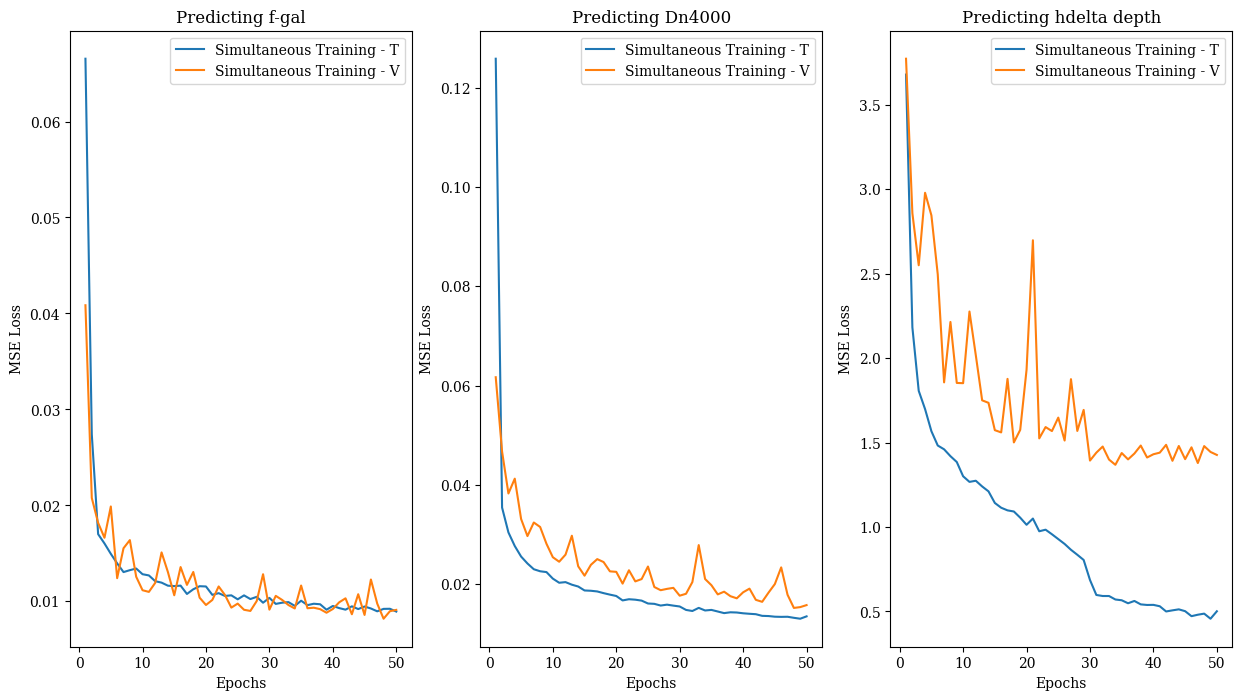

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


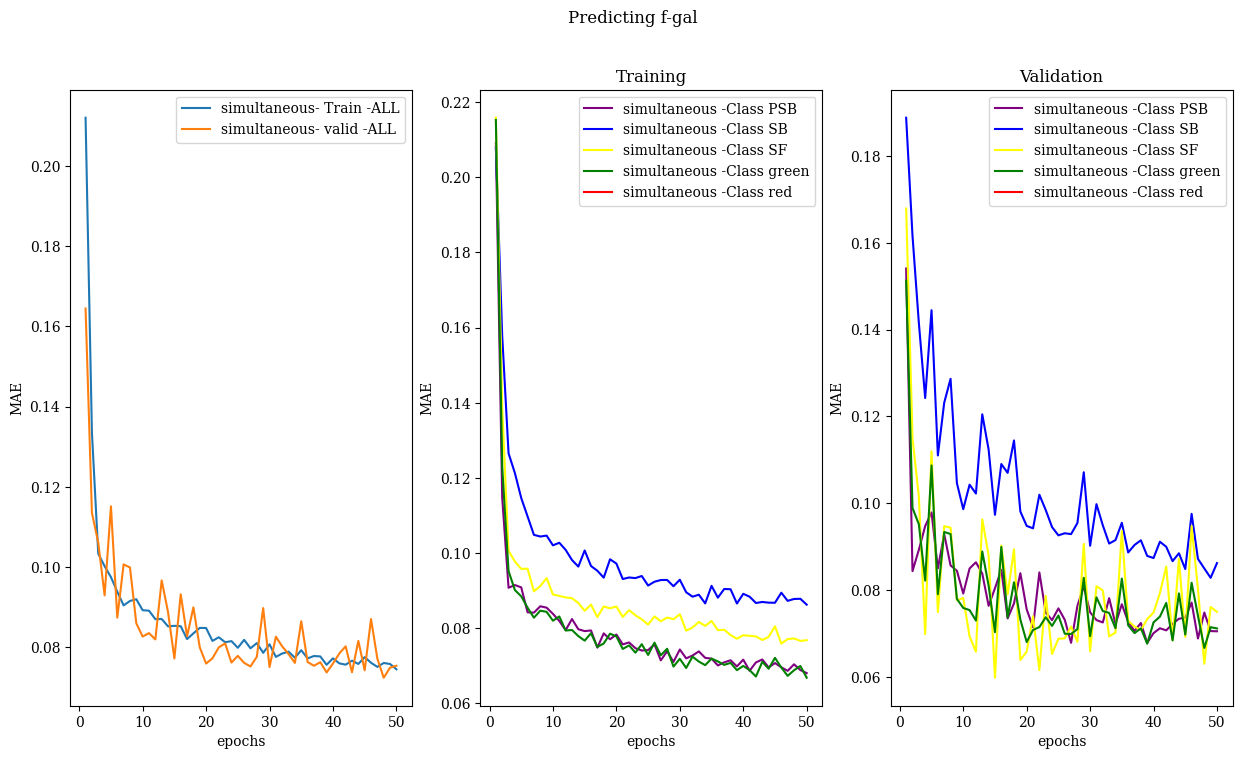

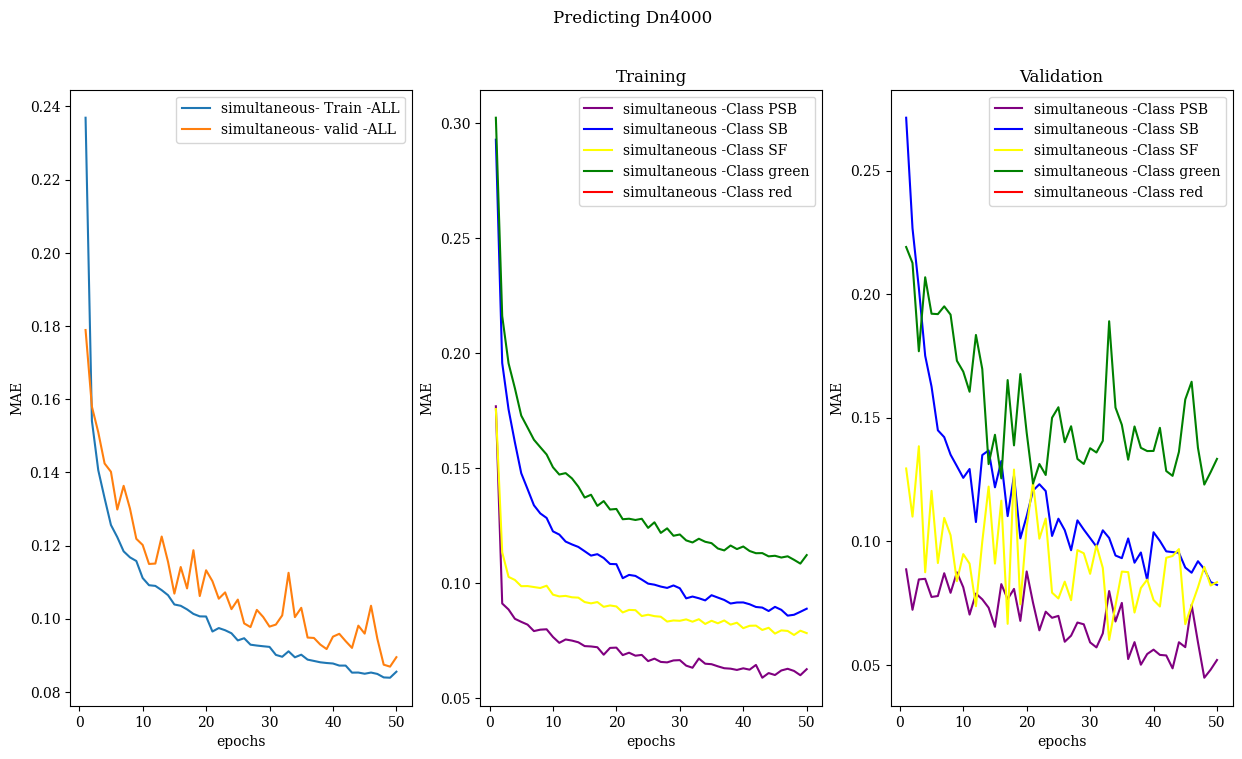

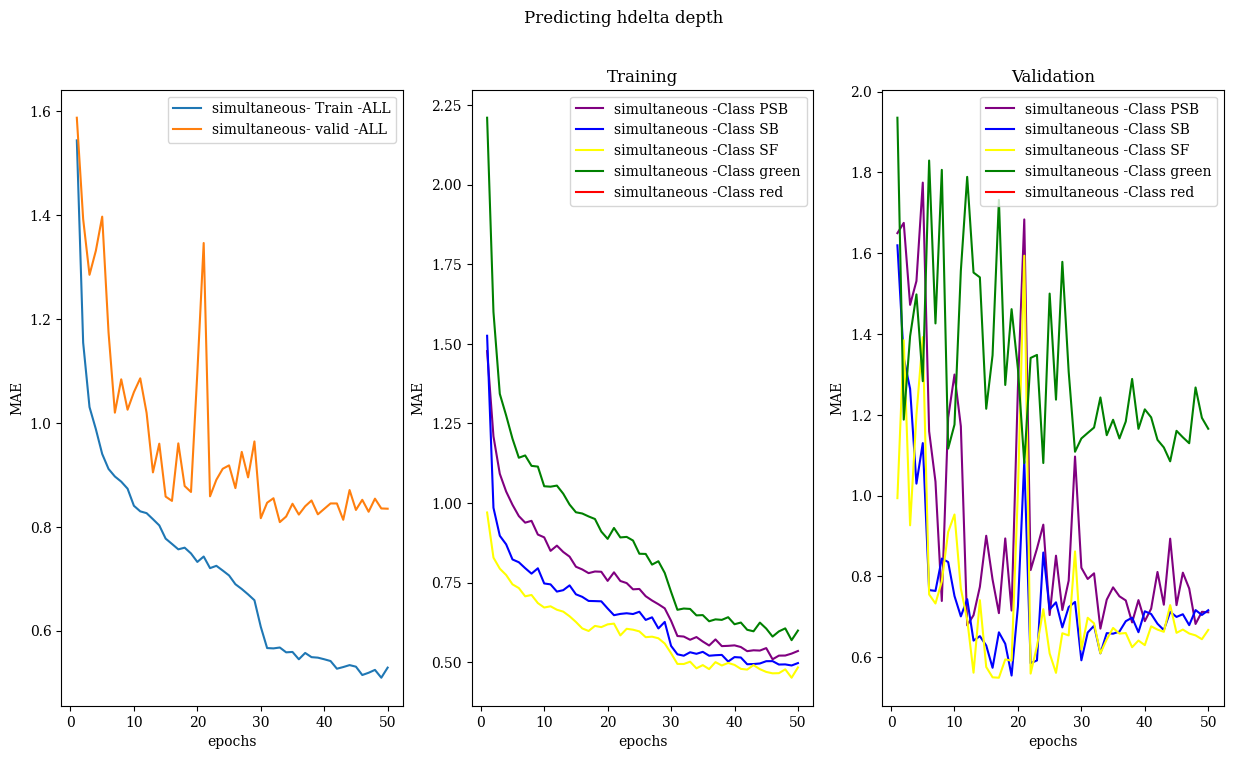

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE[0]
M3_fgal_MAEValidLossCurve=ALLMAE[3]

M3_dn4_MAETrainLossCurve=ALLMAE[1]
M3_dn4_MAEValidLossCurve=ALLMAE[4]

M3_hdelta_MAETrainLossCurve=ALLMAE[2]
M3_hdelta_MAEValidLossCurve=ALLMAE[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

## Remove ultra high dn4000 and oversample the remaing red gals

### make dataloaders for the simul traning model


In [20]:
# oversampling and undersample should occur on train set not other set to prevent data leakage
from sklearn.model_selection import train_test_split
train, test= train_test_split(firstDataset, test_size=0.1)
train, valid =train_test_split(train, test_size=200/9000)

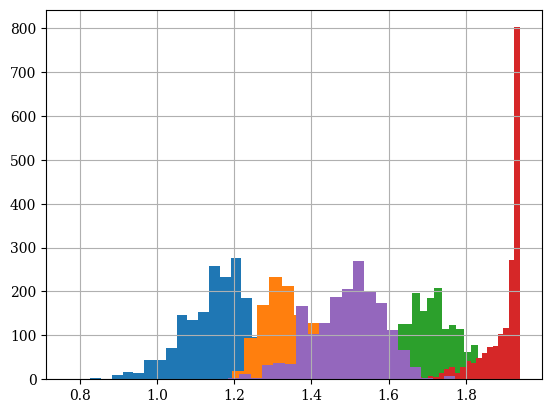

In [21]:
for i in ['SB', 'SF','green', 'red','PSB']:
    train[train['gal_type'] == i]['dn4000'].hist(bins=20)

(954, 804, 1758)

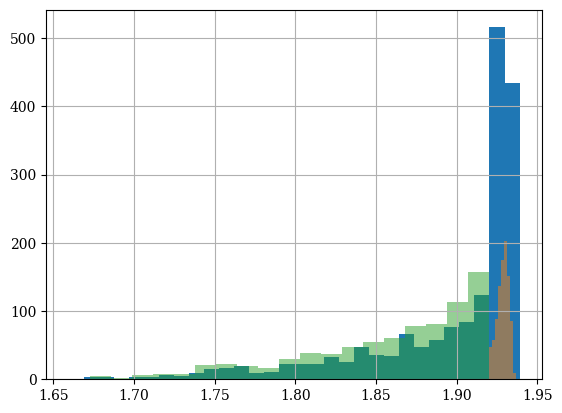

In [22]:
RedDataset=train[train['gal_type'] == 'red']
RedDataset['dn4000'].hist(bins=30, density=False)
highDN4=RedDataset[RedDataset['dn4000']>1.92]['dn4000']
lowDN4=RedDataset[RedDataset['dn4000']<=1.92]['dn4000']
highDN4.hist(bins=10, alpha=0.5, density=False)
lowDN4.hist(bins=20, alpha=0.5, density=False)
len(highDN4), len(lowDN4),len(RedDataset)


1558

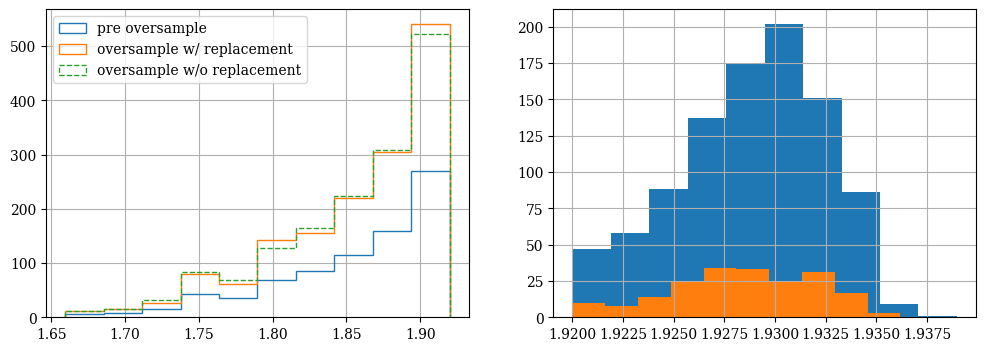

In [23]:
# keep the first 150 in high dn4 len(lowdn)=801, 801 + 200 =1001, remaing amount to over sample len(red)-1001, 1761-1001=760
highRedDN4000=RedDataset[RedDataset['dn4000']>1.92]
lowRedDN4000=RedDataset[RedDataset['dn4000']<=1.92]
first200HighDn4000=pd.DataFrame(highRedDN4000.sample(n=200))

# randomly oversample the lowdn4 for 760 more spectra
oversamplelowdn4W_Replacement=lowRedDN4000.sample(n=len(RedDataset)-(len(lowDN4)+len(first200HighDn4000)), replace=True)
oversamplelowdn4WO_Replacement=lowRedDN4000.sample(n=len(RedDataset)-(len(lowDN4)+len(first200HighDn4000)), replace=False)

# combine back with lowDn4000 values
oversamplelowdn4W_Replacement=pd.concat([lowRedDN4000, oversamplelowdn4W_Replacement])
oversamplelowdn4WO_Replacement=pd.concat([lowRedDN4000, oversamplelowdn4WO_Replacement])

fig, ax=plt.subplots(figsize=(12,4),ncols=2)
#fig1, ax1=plt.subplots(figsize=(4,3))

highRedDN4000['dn4000'].hist(ax=ax[1])
first200HighDn4000['dn4000'].hist(ax=ax[1])

lowRedDN4000['dn4000'].hist(ax=ax[0], histtype='step', label='pre oversample')
oversamplelowdn4W_Replacement['dn4000'].hist(ax=ax[0], histtype='step',label='oversample w/ replacement')
oversamplelowdn4WO_Replacement['dn4000'].hist(ax=ax[0], histtype='step',label='oversample w/o replacement',linestyle='--')

ax[0].legend()

len(oversamplelowdn4W_Replacement)

(1758, 1758)

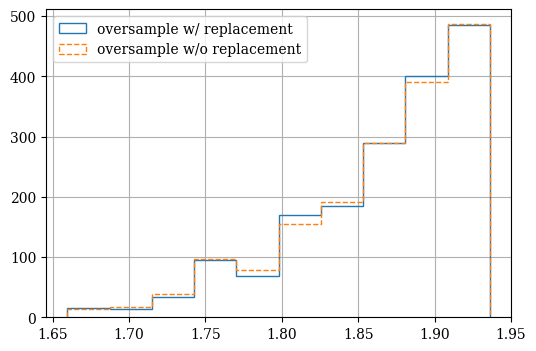

In [24]:
oversampledRedGalaxies_W_Replace=pd.concat([oversamplelowdn4W_Replacement,first200HighDn4000])
oversampledRedGalaxies_WO_Replace=pd.concat([oversamplelowdn4WO_Replacement,first200HighDn4000])

fig, ax=plt.subplots(figsize=(6,4))

oversampledRedGalaxies_W_Replace['dn4000'].hist(ax=ax, histtype='step',label='oversample w/ replacement')
oversampledRedGalaxies_WO_Replace['dn4000'].hist(ax=ax, histtype='step',label='oversample w/o replacement',linestyle='--')

ax.legend()
len(oversampledRedGalaxies_W_Replace), len(oversampledRedGalaxies_WO_Replace)


Text(0.5, 1.0, 'Oversampled RED without replacement Dataset')

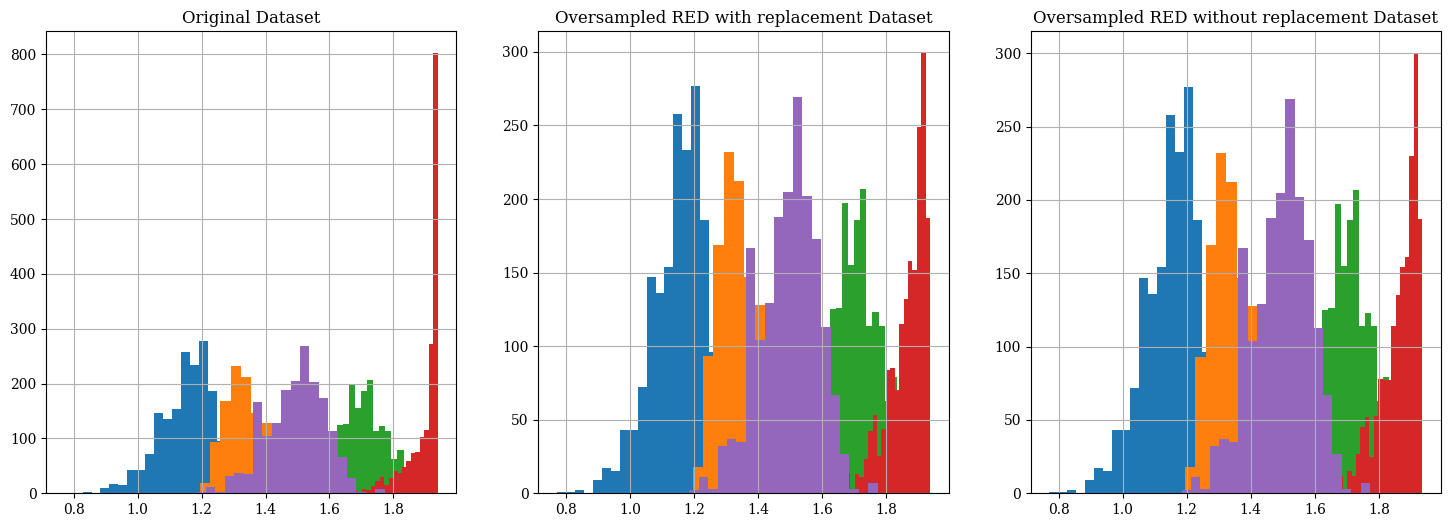

In [25]:
sansRedDataset=train[train['gal_type'] != 'red']
OSWR_datset=pd.concat([sansRedDataset, oversampledRedGalaxies_W_Replace])
OSWoR_datset=pd.concat([sansRedDataset, oversampledRedGalaxies_WO_Replace])

fig,ax=plt.subplots(figsize=(18,6), ncols=3)
for i in ['SB', 'SF','green', 'red','PSB']:
    train[train['gal_type'] == i]['dn4000'].hist(bins=20, ax=ax[0])
    OSWR_datset[OSWR_datset['gal_type'] == i]['dn4000'].hist(bins=20, ax=ax[1])
    OSWoR_datset[OSWoR_datset['gal_type'] == i]['dn4000'].hist(bins=20, ax=ax[2])

ax[0].set_title('Original Dataset')
ax[1].set_title('Oversampled RED with replacement Dataset')
ax[2].set_title('Oversampled RED without replacement Dataset')

In [26]:
# Dataset class for simultaneous traning model
class fullDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, fraction, galTypeCode,dn4000,hdelta):
    self.data=flux
    self.f_gal=fraction
    self.galTypeCode=galTypeCode
    self.dn4=dn4000
    self.hdelta=hdelta
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorF_gal=torch.Tensor(self.f_gal)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensordn4=torch.Tensor(self.dn4)
    self.tensorhdel=torch.Tensor(self.hdelta)


  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorF_gal[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    dn4_indexed = self.tensordn4[index]
    hdelta_indexed = self.tensorhdel[index]

    return data_point, data_f_gal, gal_typeCode, dn4_indexed,hdelta_indexed

  def  __len__(self):
    return self.size

#create dataset
fullDataset_withReplacemnt=fullDataSetClass(OSWR_datset['flux'].to_list(), OSWR_datset['f_gal'].to_list(), OSWR_datset['gal_type_code'].to_list(),OSWR_datset['dn4000'].to_list(),OSWR_datset['hdelta'].to_list())
fullDataset_withoutReplacemnt=fullDataSetClass(OSWoR_datset['flux'].to_list(), OSWoR_datset['f_gal'].to_list(), OSWoR_datset['gal_type_code'].to_list(),OSWoR_datset['dn4000'].to_list(),OSWoR_datset['hdelta'].to_list())

valid=fullDataSetClass(valid['flux'].to_list(), valid['f_gal'].to_list(), valid['gal_type_code'].to_list(),valid['dn4000'].to_list(),valid['hdelta'].to_list())
test=fullDataSetClass(test['flux'].to_list(), test['f_gal'].to_list(), test['gal_type_code'].to_list(),test['dn4000'].to_list(),test['hdelta'].to_list())

In [27]:
#split data set into train, validation, test
trainDataset_OSWR=torch.utils.data.random_split(fullDataset_withReplacemnt, [8800])[0]
validDataset_OSWR=torch.utils.data.random_split(valid, [200])[0]
testDataset_OSWR = torch.utils.data.random_split(test, [1000])[0]
trainDataset_OSWoR= torch.utils.data.random_split(fullDataset_withReplacemnt, [8800])[0]
validDataset_OSWoR=torch.utils.data.random_split(valid, [200])[0]
testDataset_OSWoR = torch.utils.data.random_split(test, [1000])[0]

In [28]:

# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader_OSWR = data.DataLoader(trainDataset_OSWR, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_OSWR = data.DataLoader(validDataset_OSWR, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_OSWR = data.DataLoader(testDataset_OSWR, batch_size=500, shuffle=False)


train_data_loader_OSWoR = data.DataLoader(trainDataset_OSWoR, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_OSWoR = data.DataLoader(validDataset_OSWoR, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_OSWoR = data.DataLoader(testDataset_OSWoR, batch_size=500, shuffle=False)

### defining and Training models: oversample with replacement

In [ ]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.000,momentum=0.9) # no weight decay!!!!!!
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=50

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, ALLMAE=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader_OSWR, valid_data_loader_OSWR,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/50 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.015311106 Validation Loss: 0.0136642512 lr: 0.001
Model-Dn4000| Train loss: 0.0282392881 Validation Loss: 0.0292961067 lr: 0.001
Model-Hdelta| Train loss: 2.0795089256 Validation Loss: 2.1713577509 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0125444828 Validation Loss: 0.0097093745 lr: 0.001
Model-Dn4000| Train loss: 0.0229820636 Validation Loss: 0.0245272154 lr: 0.001
Model-Hdelta| Train loss: 1.665592056 Validation Loss: 1.7241114378 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0114430464 Validation Loss: 0.0095203305 lr: 0.001
Model-Dn4000| Train loss: 0.0207979351 Validation Loss: 0.0308768405 lr: 0.001
Model-Hdelta| Train loss: 1.3937080687 Validation Loss: 1.9212790728 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0097774988 Validation Loss: 0.0108542088 lr: 0.001
Model-Dn4000| Train loss:

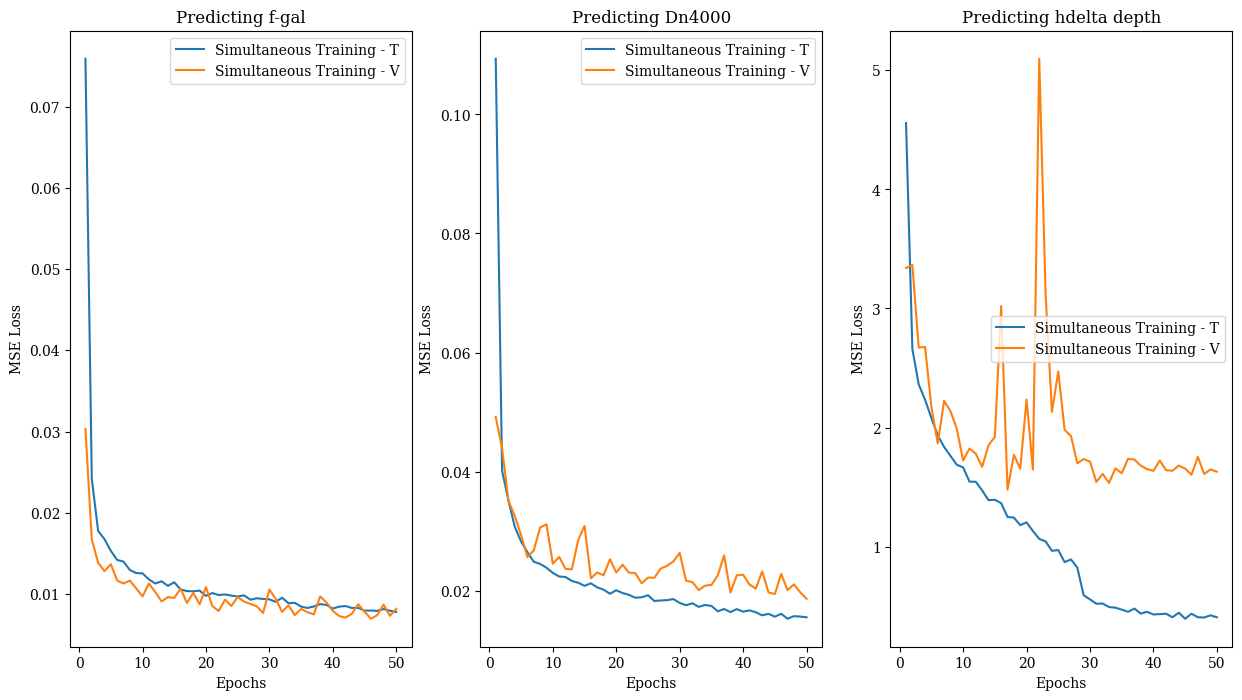

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


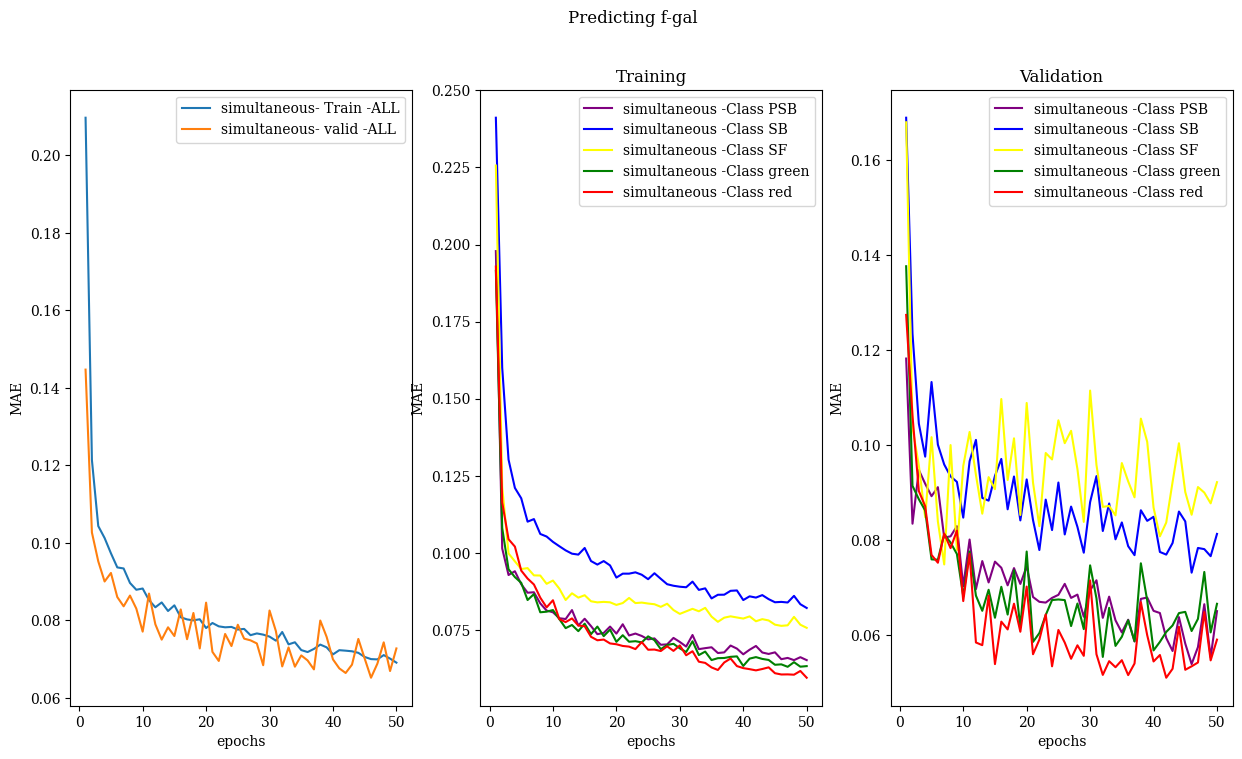

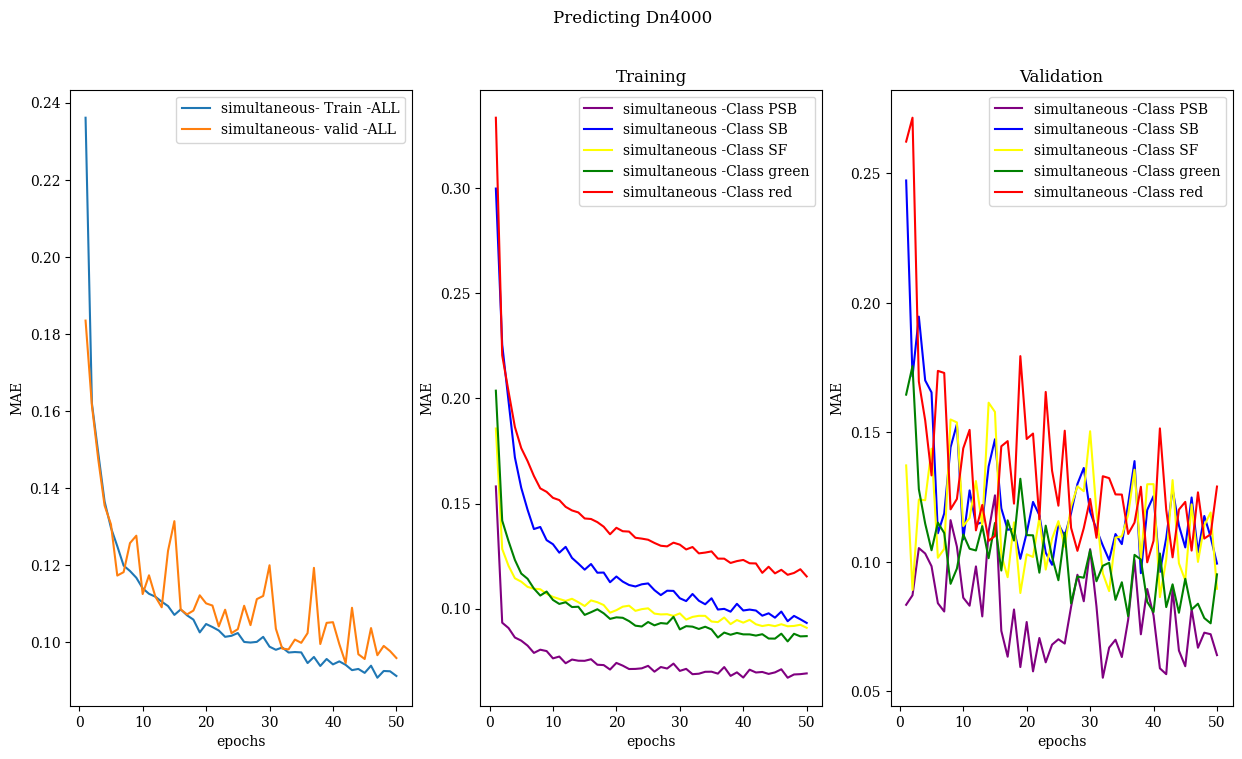

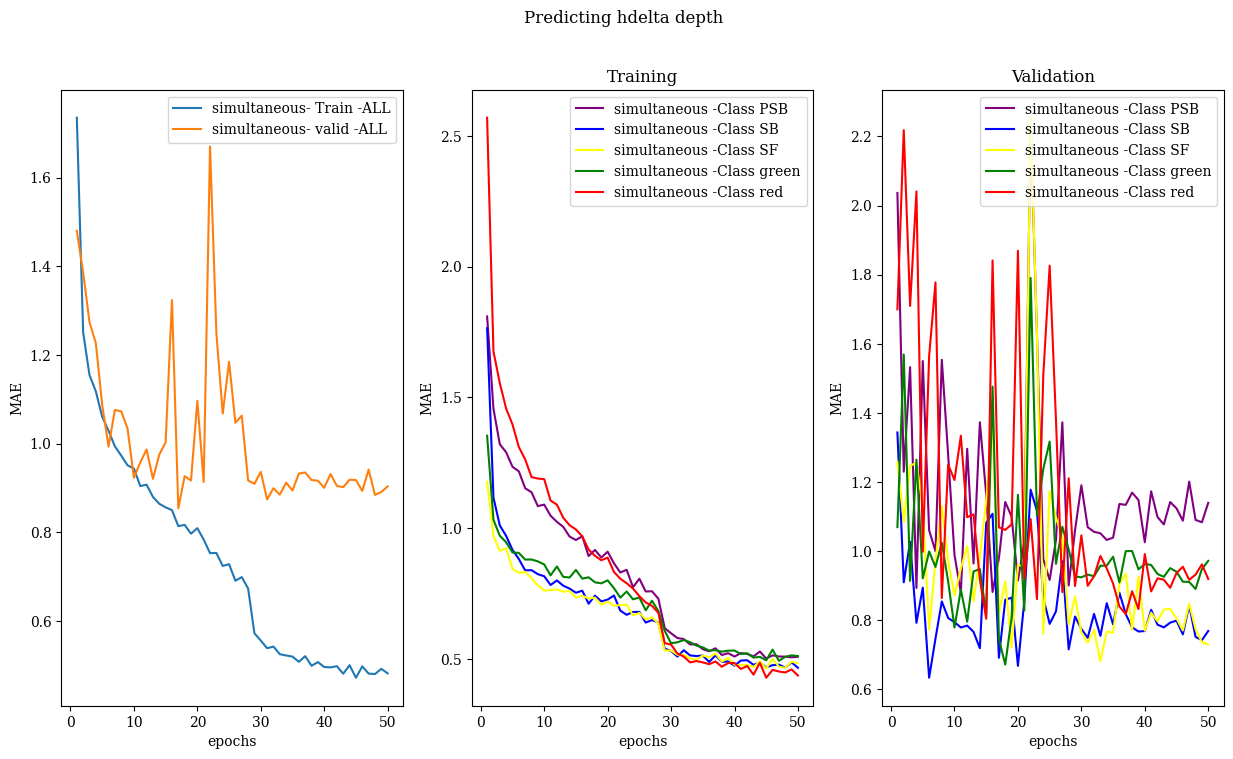

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE[0]
M3_fgal_MAEValidLossCurve=ALLMAE[3]

M3_dn4_MAETrainLossCurve=ALLMAE[1]
M3_dn4_MAEValidLossCurve=ALLMAE[4]

M3_hdelta_MAETrainLossCurve=ALLMAE[2]
M3_hdelta_MAEValidLossCurve=ALLMAE[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

In [ ]:
graphTrain_dataset_OSWR_1=graphDatasetmodifier(trainDataset_OSWR, None, None)
graphValid_dataset_OSWR_1=graphDatasetmodifier(validDataset_OSWR, None, None)

graphTrain_data_loader_OSWR_1 = data.DataLoader(graphTrain_dataset_OSWR_1, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_1 = data.DataLoader(graphValid_dataset_OSWR_1, batch_size=VALID_BATCH_SIZE, shuffle=False)


trainGraphdata_OSWR_fgal,validGraphdata_OSWR_fgal= dataFor_graphPredictionTruth(model_fgal_simul, graphTrain_data_loader_OSWR_1,
                                                                                graphValid_data_loader_OSWR_1,  None, 'gal_type','f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_OSWR_2=graphDatasetmodifier(graphTrain_dataset_OSWR_1, trainGraphdata_OSWR_fgal[0], None)
graphValid_dataset_OSWR_2=graphDatasetmodifier(graphValid_dataset_OSWR_1, validGraphdata_OSWR_fgal[0], None)

graphTrain_data_loader_OSWR_2 = data.DataLoader(graphTrain_dataset_OSWR_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_2 = data.DataLoader(graphValid_dataset_OSWR_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_OSWR_dn4,validGraphdata_OSWR_dn4= dataFor_graphPredictionTruth(model_dn4_simul, graphTrain_data_loader_OSWR_2,
                                                                              graphValid_data_loader_OSWR_2, None, 'gal_type','dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_OSWR_3=graphDatasetmodifier(graphTrain_dataset_OSWR_2, None, trainGraphdata_OSWR_dn4[0])
graphValid_dataset_OSWR_3=graphDatasetmodifier(graphValid_dataset_OSWR_2, None, validGraphdata_OSWR_dn4[0])

graphTrain_data_loader_OSWR_3 = data.DataLoader(graphTrain_dataset_OSWR_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_3 = data.DataLoader(graphValid_dataset_OSWR_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_OSWR_hdel,validGraphdata_OSWR_hdel= dataFor_graphPredictionTruth(model_hdel_simul, graphTrain_data_loader_OSWR_3,
                                                                                graphTrain_data_loader_OSWR_3, None, 'gal_type','hdelta')

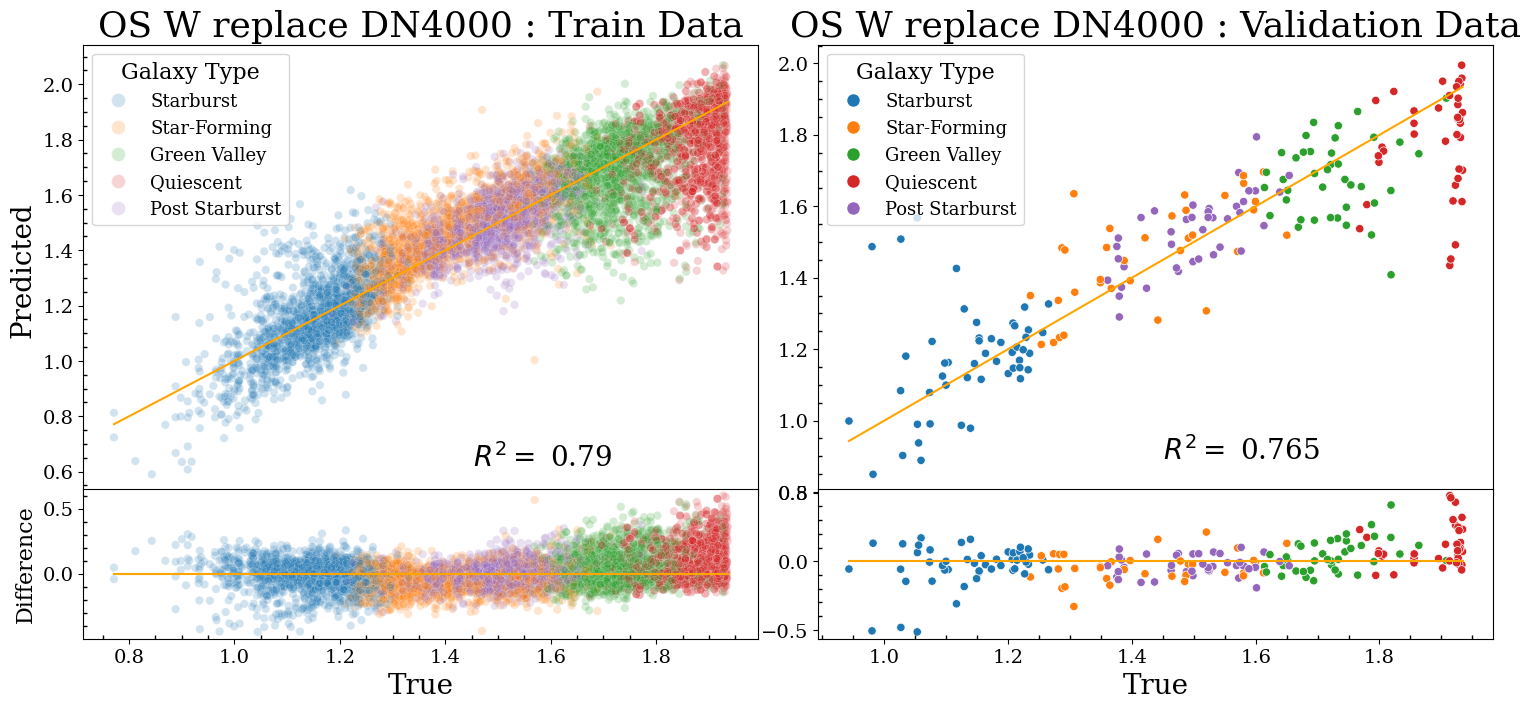

In [ ]:
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphdata_OSWR_dn4,*validGraphdata_OSWR_dn4, 'OS W replace DN4000 ',ax, True, le)

### train oversample without replacement model

In [29]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.000,momentum=0.9) # no weight decay!!!!!!
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=50

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, ALLMAE=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader_OSWoR, valid_data_loader_OSWoR,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/50 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.0120206456 Validation Loss: 0.0148294889 lr: 0.001
Model-Dn4000| Train loss: 0.0307951746 Validation Loss: 0.0328303259 lr: 0.001
Model-Hdelta| Train loss: 2.10707365 Validation Loss: 2.1410968304 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0097025299 Validation Loss: 0.0143994782 lr: 0.001
Model-Dn4000| Train loss: 0.0259816976 Validation Loss: 0.0415737052 lr: 0.001
Model-Hdelta| Train loss: 1.6708995379 Validation Loss: 1.7122694254 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0089285876 Validation Loss: 0.0107656405 lr: 0.001
Model-Dn4000| Train loss: 0.0239072566 Validation Loss: 0.0295043606 lr: 0.001
Model-Hdelta| Train loss: 1.402769338 Validation Loss: 2.3741157055 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0079962183 Validation Loss: 0.0092791901 lr: 0.001
Model-Dn4000| Train loss: 

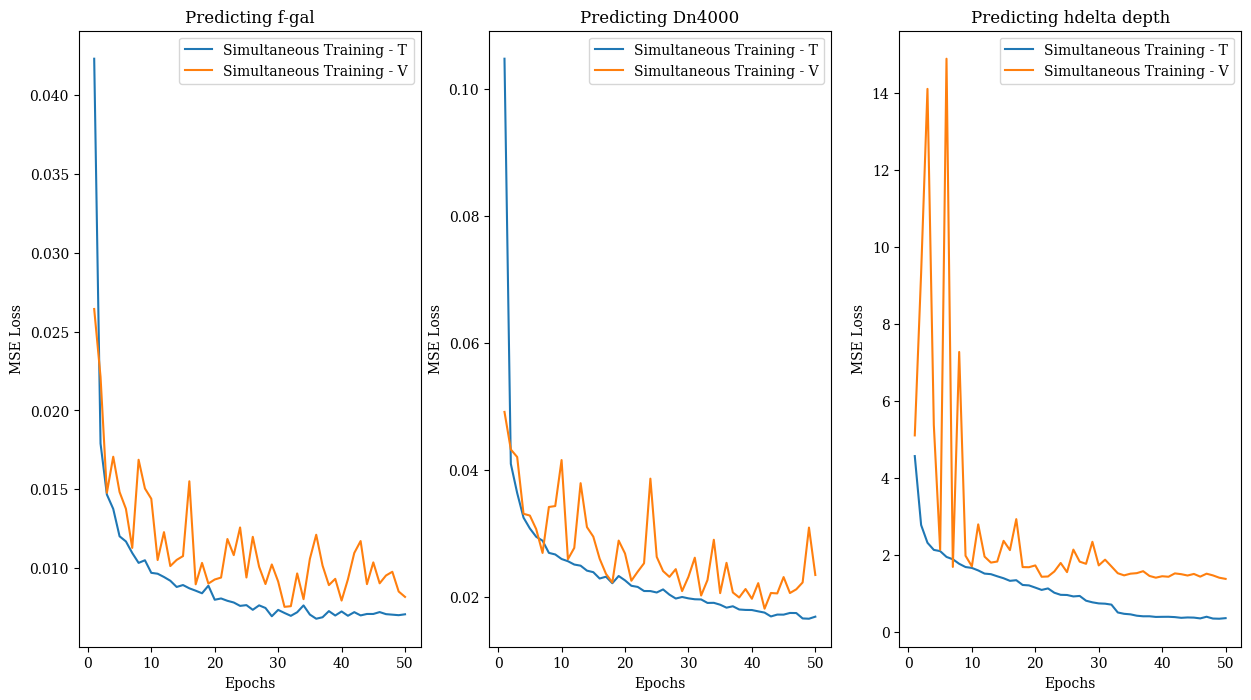

In [30]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


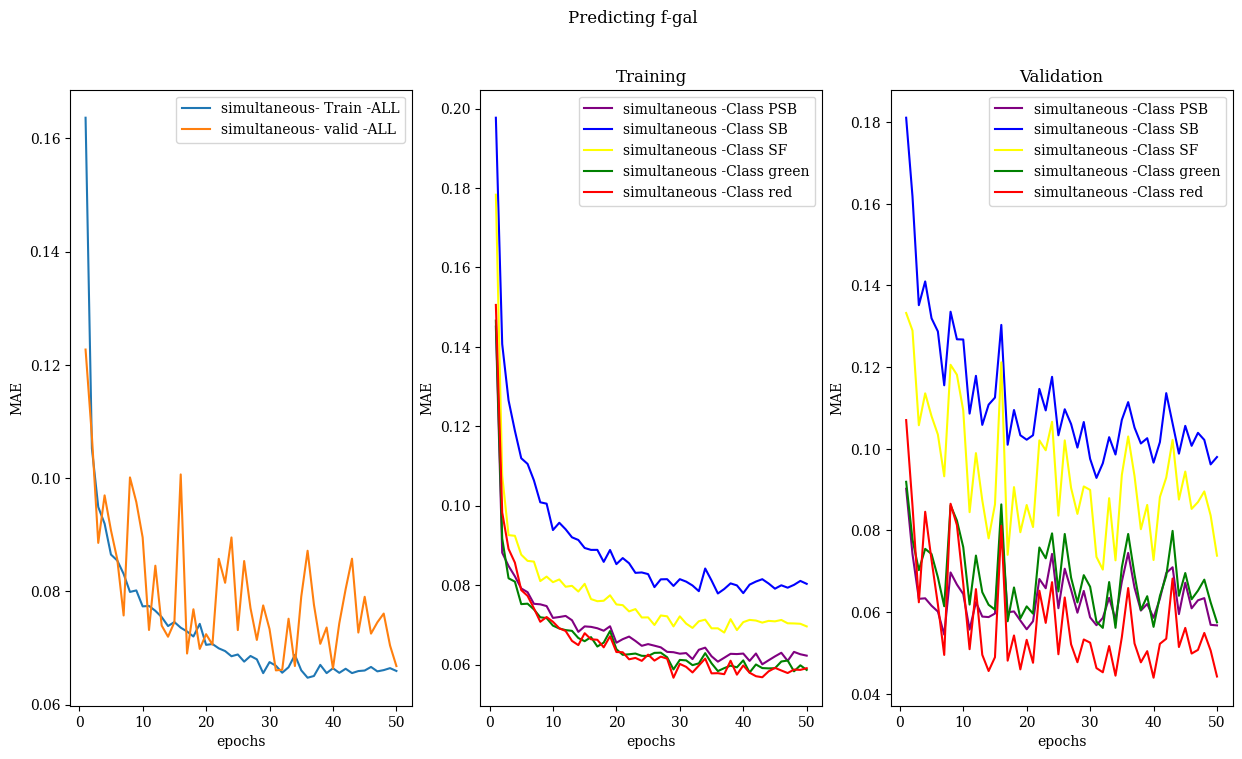

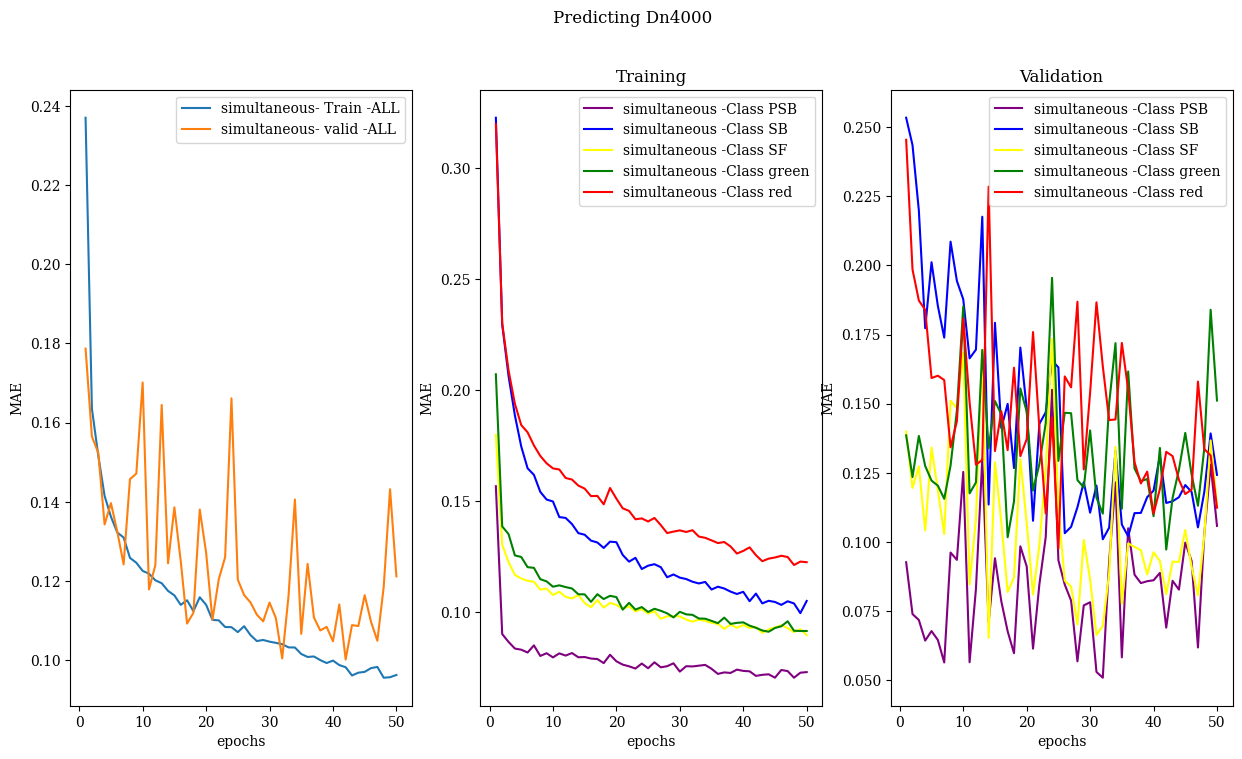

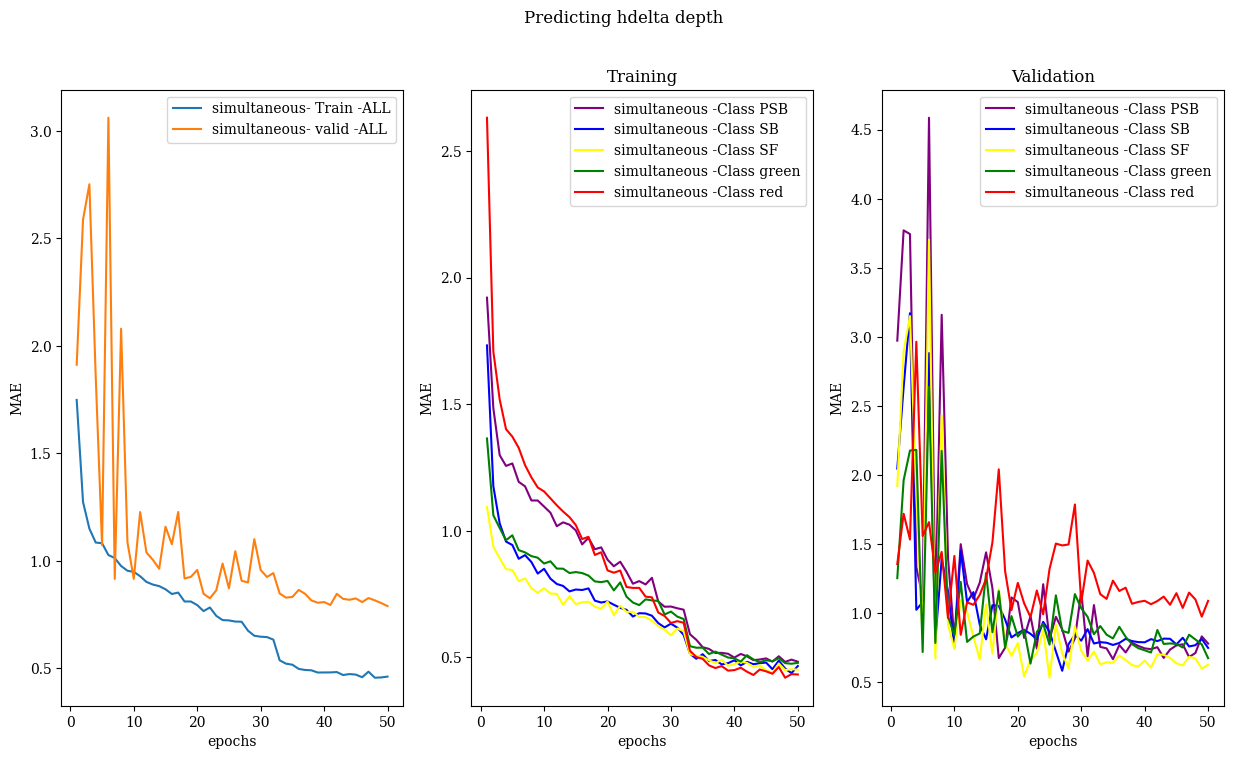

In [31]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE[0]
M3_fgal_MAEValidLossCurve=ALLMAE[3]

M3_dn4_MAETrainLossCurve=ALLMAE[1]
M3_dn4_MAEValidLossCurve=ALLMAE[4]

M3_hdelta_MAETrainLossCurve=ALLMAE[2]
M3_hdelta_MAEValidLossCurve=ALLMAE[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

In [32]:
graphTrain_dataset_OSWR_1=graphDatasetmodifier(trainDataset_OSWR, None, None)
graphValid_dataset_OSWR_1=graphDatasetmodifier(validDataset_OSWR, None, None)

graphTrain_data_loader_OSWR_1 = data.DataLoader(graphTrain_dataset_OSWR_1, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_1 = data.DataLoader(graphValid_dataset_OSWR_1, batch_size=VALID_BATCH_SIZE, shuffle=False)


trainGraphdata_OSWR_fgal,validGraphdata_OSWR_fgal= dataFor_graphPredictionTruth(model_fgal_simul, graphTrain_data_loader_OSWR_1,
                                                                                graphValid_data_loader_OSWR_1,  None, 'gal_type','f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_OSWR_2=graphDatasetmodifier(graphTrain_dataset_OSWR_1, trainGraphdata_OSWR_fgal[0], None)
graphValid_dataset_OSWR_2=graphDatasetmodifier(graphValid_dataset_OSWR_1, validGraphdata_OSWR_fgal[0], None)

graphTrain_data_loader_OSWR_2 = data.DataLoader(graphTrain_dataset_OSWR_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_2 = data.DataLoader(graphValid_dataset_OSWR_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_OSWR_dn4,validGraphdata_OSWR_dn4= dataFor_graphPredictionTruth(model_dn4_simul, graphTrain_data_loader_OSWR_2,
                                                                              graphValid_data_loader_OSWR_2, None, 'gal_type','dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_OSWR_3=graphDatasetmodifier(graphTrain_dataset_OSWR_2, None, trainGraphdata_OSWR_dn4[0])
graphValid_dataset_OSWR_3=graphDatasetmodifier(graphValid_dataset_OSWR_2, None, validGraphdata_OSWR_dn4[0])

graphTrain_data_loader_OSWR_3 = data.DataLoader(graphTrain_dataset_OSWR_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_OSWR_3 = data.DataLoader(graphValid_dataset_OSWR_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_OSWR_hdel,validGraphdata_OSWR_hdel= dataFor_graphPredictionTruth(model_hdel_simul, graphTrain_data_loader_OSWR_3,
                                                                                graphTrain_data_loader_OSWR_3, None, 'gal_type','hdelta')

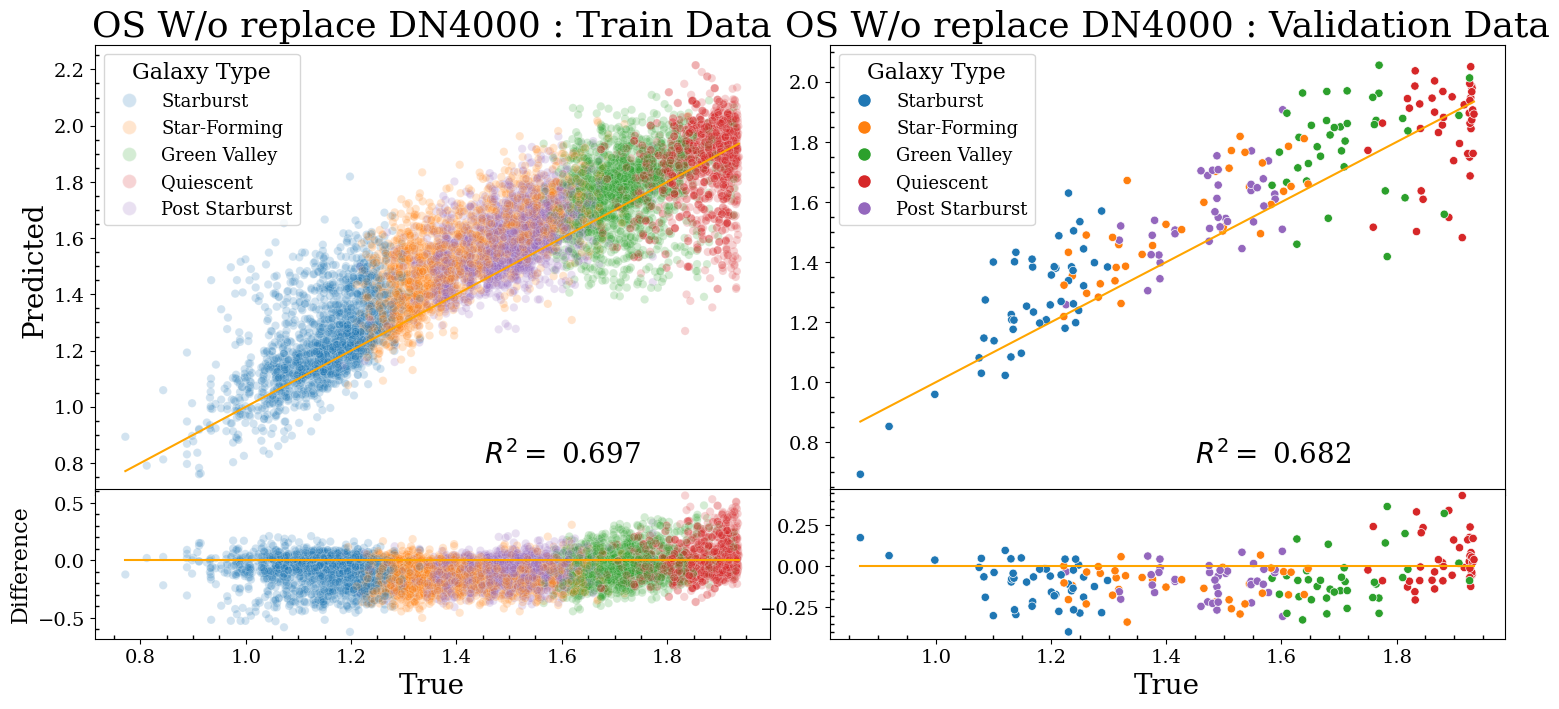

In [33]:
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphdata_OSWR_dn4,*validGraphdata_OSWR_dn4, 'OS W/o replace DN4000 ',ax, True, le)

## Test if generalisation is the advantage of Simul training

make train dataset, use same dataset in both cases, in 2nd cases make training loop use random f-gal values

### make data loader for this section

In [ ]:
fullDataset_simul_traning=fullDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'],firstDataset['dn4000'],firstDataset['hdelta'])

In [ ]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_simul_traning, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [ ]:
import torch.utils.data as data
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader = data.DataLoader(trainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=False)

### train loop for randomised predictions

In [ ]:
def epochLoop_RANDOMISED_PREDICTIONS(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    M3_fgal_trainLossCurve=[]
    M3_fgal_validLossCurve=[]
    M3_dn4_trainLossCurve=[]
    M3_dn4_validLossCurve=[]
    M3_hdelta_trainLossCurve=[]
    M3_hdelta_validLossCurve=[]

    classdiffVSepoch_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_hdelta=[[],[],[],[],[],[]]

    classdiffVSepoch_valid_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_hdelta=[[],[],[],[],[],[]]

    allClass=[classdiffVSepoch_fgal, classdiffVSepoch_dn4, classdiffVSepoch_hdelta, classdiffVSepoch_valid_fgal, classdiffVSepoch_valid_dn4, classdiffVSepoch_valid_hdelta]

    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0

        allPredictionDiffs_fgal=np.array([[],[]])
        allPredictionDiffs_dn4=np.array([[],[]])
        allPredictionDiffs_hdelta=np.array([[],[]])

        allPredictionDiffs_valid_fgal=np.array([[],[]])
        allPredictionDiffs_valid_dn4=np.array([[],[]])
        allPredictionDiffs_valid_hdelta=np.array([[],[]])

        for batch_flux, batch_f_gal, batch_hue , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux

            fgalarray_shape=f_galPrediction.shape[0]
            fake_fgalPrediction=torch.rand(fgalarray_shape)
            expandablePrediction=fake_fgalPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal)

            allPredictionDiffs_fgal=[np.append(allPredictionDiffs_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_fgal[1]]
            allPredictionDiffs_fgal=[allPredictionDiffs_fgal[0],np.append(allPredictionDiffs_fgal[1], batch_hue.cpu().numpy())]


            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            dn4array_shape=dn4Prediction.shape[0]
            fake_dn4Prediction=torch.rand(dn4array_shape)

            expandablePrediction=fake_dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4)
            allPredictionDiffs_dn4=[np.append(allPredictionDiffs_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_dn4[1]]
            allPredictionDiffs_dn4=[allPredictionDiffs_dn4[0],np.append(allPredictionDiffs_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdeltaPrediction = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            predictionDiff=abs(hdeltaPrediction - batch_hdel)
            allPredictionDiffs_hdelta=[np.append(allPredictionDiffs_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_hdelta[1]]
            allPredictionDiffs_hdelta=[allPredictionDiffs_hdelta[0],np.append(allPredictionDiffs_hdelta[1], batch_hue.cpu().numpy())]

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, batch_hue , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux


            fgalarray_shape=f_galPrediction.shape[0]
            fake_fgalPrediction=torch.rand(fgalarray_shape)

            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal_V)
            allPredictionDiffs_valid_fgal=[np.append(allPredictionDiffs_valid_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_fgal[1]]
            allPredictionDiffs_valid_fgal=[allPredictionDiffs_valid_fgal[0],np.append(allPredictionDiffs_valid_fgal[1], batch_hue.cpu().numpy())]

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            dn4array_shape=dn4Prediction.shape[0]
            fake_dn4Prediction=torch.rand(dn4array_shape)

            expandablePrediction=fake_dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4_V)
            allPredictionDiffs_valid_dn4=[np.append(allPredictionDiffs_valid_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_dn4[1]]
            allPredictionDiffs_valid_dn4=[allPredictionDiffs_valid_dn4[0],np.append(allPredictionDiffs_valid_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdelPrediction = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            predictionDiff=abs(hdelPrediction - batch_hdel_V)
            allPredictionDiffs_valid_hdelta=[np.append(allPredictionDiffs_valid_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_hdelta[1]]
            allPredictionDiffs_valid_hdelta=[allPredictionDiffs_valid_hdelta[0],np.append(allPredictionDiffs_valid_hdelta[1], batch_hue.cpu().numpy())]

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3


        allPredictionDiffs=[allPredictionDiffs_fgal, allPredictionDiffs_dn4,allPredictionDiffs_hdelta,allPredictionDiffs_valid_fgal,allPredictionDiffs_valid_dn4,allPredictionDiffs_valid_hdelta]

        index=0
        for i in allPredictionDiffs:
            class0idx=np.where(i[1] == 0)[0]
            class1idx=np.where(i[1] == 1)[0]
            class2idx=np.where(i[1] == 2)[0]
            class3idx=np.where(i[1] == 3)[0]
            class4idx=np.where(i[1] == 4)[0]

            allClass[index]=[np.append(allClass[index][0],np.sum(i[0][class0idx])/len(class0idx)),allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],np.append(allClass[index][1],np.sum(i[0][class1idx])/len(class1idx)),allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],np.append(allClass[index][2],np.sum(i[0][class2idx])/len(class2idx)),allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],np.append(allClass[index][3],np.sum(i[0][class3idx])/len(class3idx)),allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],np.append(allClass[index][4],np.sum(i[0][class4idx])/len(class4idx)),allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],np.append(allClass[index][5],np.sum(i[0])/len(i[0]))]

            index+=1


        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        M3_fgal_trainLossCurve.append(epoch_train_loss_F_gal)
        M3_fgal_validLossCurve.append(epoch_valid_loss_F_gal)
        M3_dn4_trainLossCurve.append(epoch_train_loss_dn4)
        M3_dn4_validLossCurve.append(epoch_valid_loss_dn4)
        M3_hdelta_trainLossCurve.append(epoch_train_loss_hdel)
        M3_hdelta_validLossCurve.append(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal, 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal, 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4, 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4, 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel, 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel, 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])


    return M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, allClass

### defining and train randomised models

In [ ]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul_RAND=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_dn4_simul_RAND=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul_RAND=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul_RAND.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul_RAND.parameters(), lr=0.001, weight_decay=0.000,momentum=0.9) # no weight decay!!!!!!
optimiser_hdel= torch.optim.SGD(model_hdel_simul_RAND.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul_RAND.to(device)
model_dn4_simul_RAND.to(device)
model_hdel_simul_RAND.to(device)
epochs=50

M3_fgal_trainLossCurve_RAND, M3_fgal_validLossCurve_RAND ,M3_dn4_trainLossCurve_RAND ,M3_dn4_validLossCurve_RAND ,M3_hdelta_trainLossCurve_RAND ,M3_hdelta_validLossCurve_RAND, ALLMAE_RAND=epochLoop_RANDOMISED_PREDICTIONS(epochs, model_fgal_simul_RAND, model_dn4_simul_RAND, model_hdel_simul_RAND,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/50 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.0134867792 Validation Loss: 0.0110657751 lr: 0.001
Model-Dn4000| Train loss: 0.039972471 Validation Loss: 0.035804145 lr: 0.001
Model-Hdelta| Train loss: 2.7886347061 Validation Loss: 3.3091526031 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0108544205 Validation Loss: 0.0081925697 lr: 0.001
Model-Dn4000| Train loss: 0.0327996013 Validation Loss: 0.0328537198 lr: 0.001
Model-Hdelta| Train loss: 2.0883665965 Validation Loss: 2.1330342889 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0097475226 Validation Loss: 0.0077635038 lr: 0.001
Model-Dn4000| Train loss: 0.0292671247 Validation Loss: 0.0276114885 lr: 0.001
Model-Hdelta| Train loss: 1.7412512736 Validation Loss: 2.0195162892 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0088968644 Validation Loss: 0.0083184512 lr: 0.001
Model-Dn4000| Train loss:

### define and train Simul model

In [ ]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.000,momentum=0.9) # no weight decay!!!!!!
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=50

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, ALLMAE=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/50 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.0136868075 Validation Loss: 0.012144065 lr: 0.001
Model-Dn4000| Train loss: 0.032881789 Validation Loss: 0.0274158828 lr: 0.001
Model-Hdelta| Train loss: 2.0954763039 Validation Loss: 3.0296378136 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0110562211 Validation Loss: 0.0087375657 lr: 0.001
Model-Dn4000| Train loss: 0.0282134534 Validation Loss: 0.0231148032 lr: 0.001
Model-Hdelta| Train loss: 1.7916076628 Validation Loss: 2.0657637119 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0099585052 Validation Loss: 0.0085441153 lr: 0.001
Model-Dn4000| Train loss: 0.0254920536 Validation Loss: 0.0227726921 lr: 0.001
Model-Hdelta| Train loss: 1.5323104165 Validation Loss: 1.6674108505 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0092429941 Validation Loss: 0.0073138443 lr: 0.001
Model-Dn4000| Train loss:

### Plots

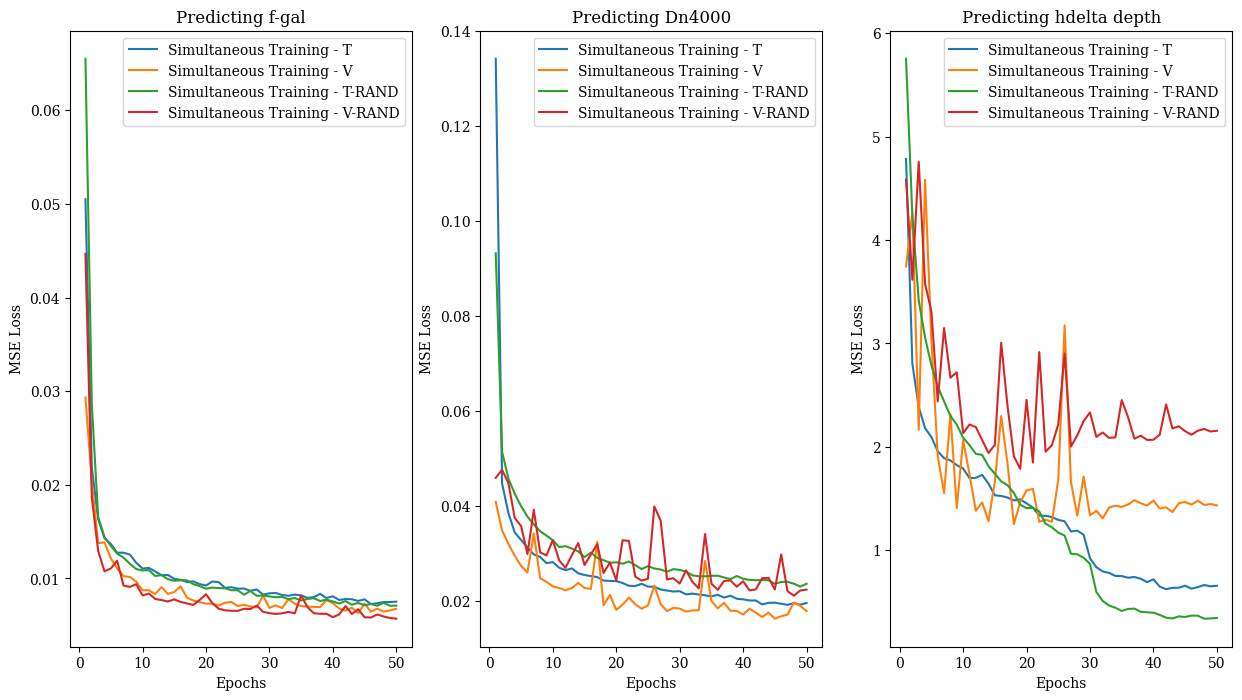

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].plot(epoch_array,M3_fgal_trainLossCurve_RAND, label='Simultaneous Training - T-RAND')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve_RAND, label='Simultaneous Training - T-RAND')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve_RAND, label='Simultaneous Training - T-RAND')
ax[0].plot(epoch_array,M3_fgal_validLossCurve_RAND, label='Simultaneous Training - V-RAND')
ax[1].plot(epoch_array,M3_dn4_validLossCurve_RAND, label='Simultaneous Training - V-RAND')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve_RAND, label='Simultaneous Training - V-RAND')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


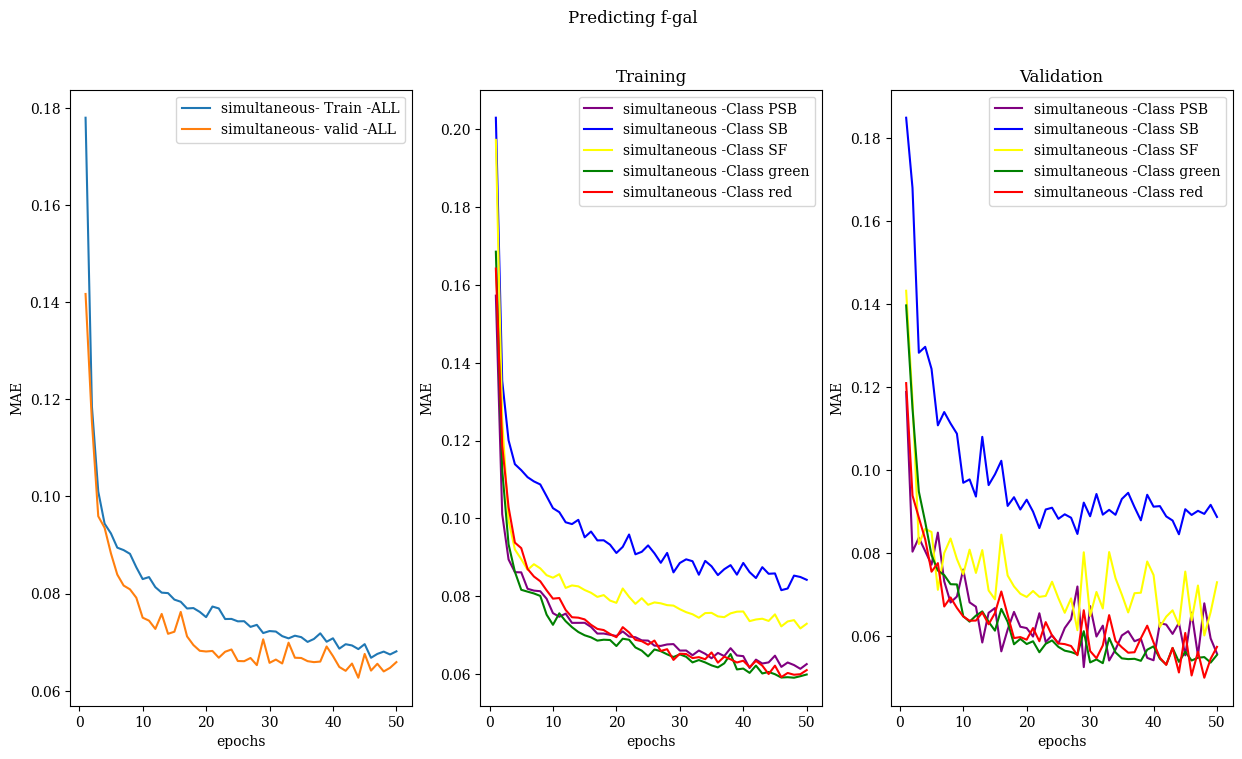

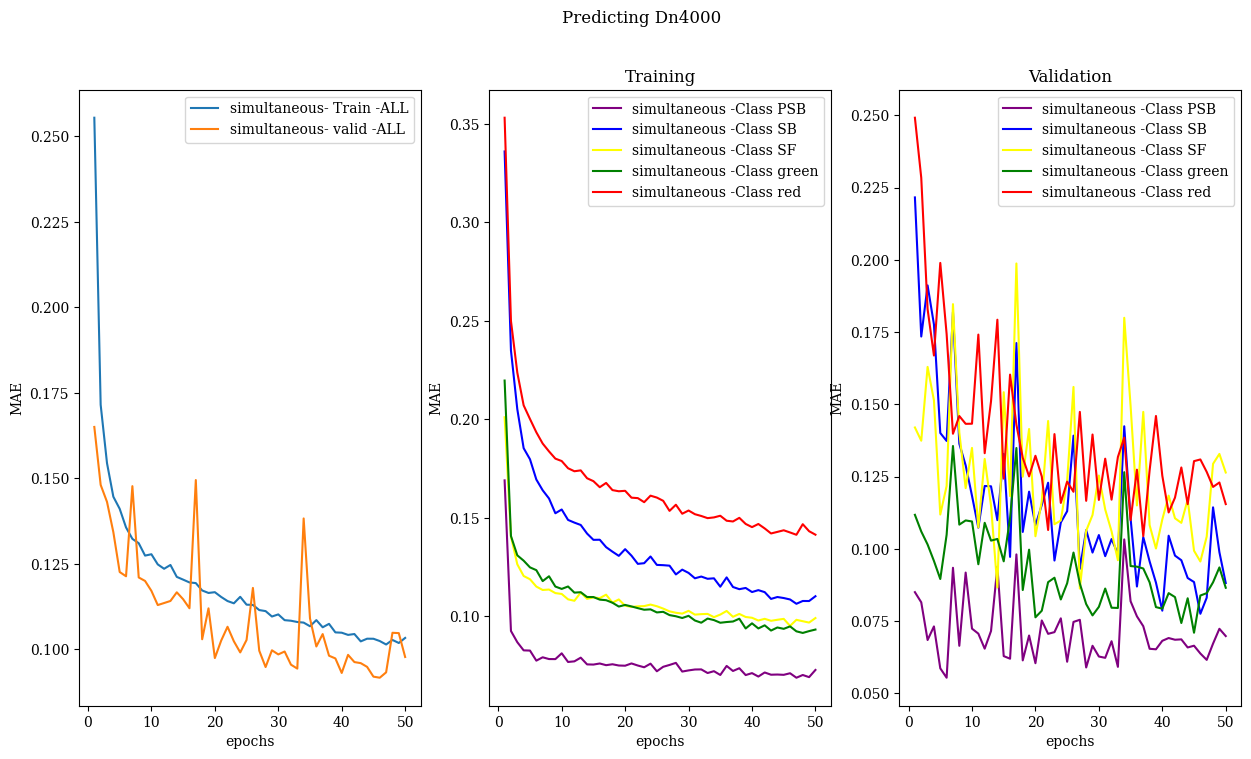

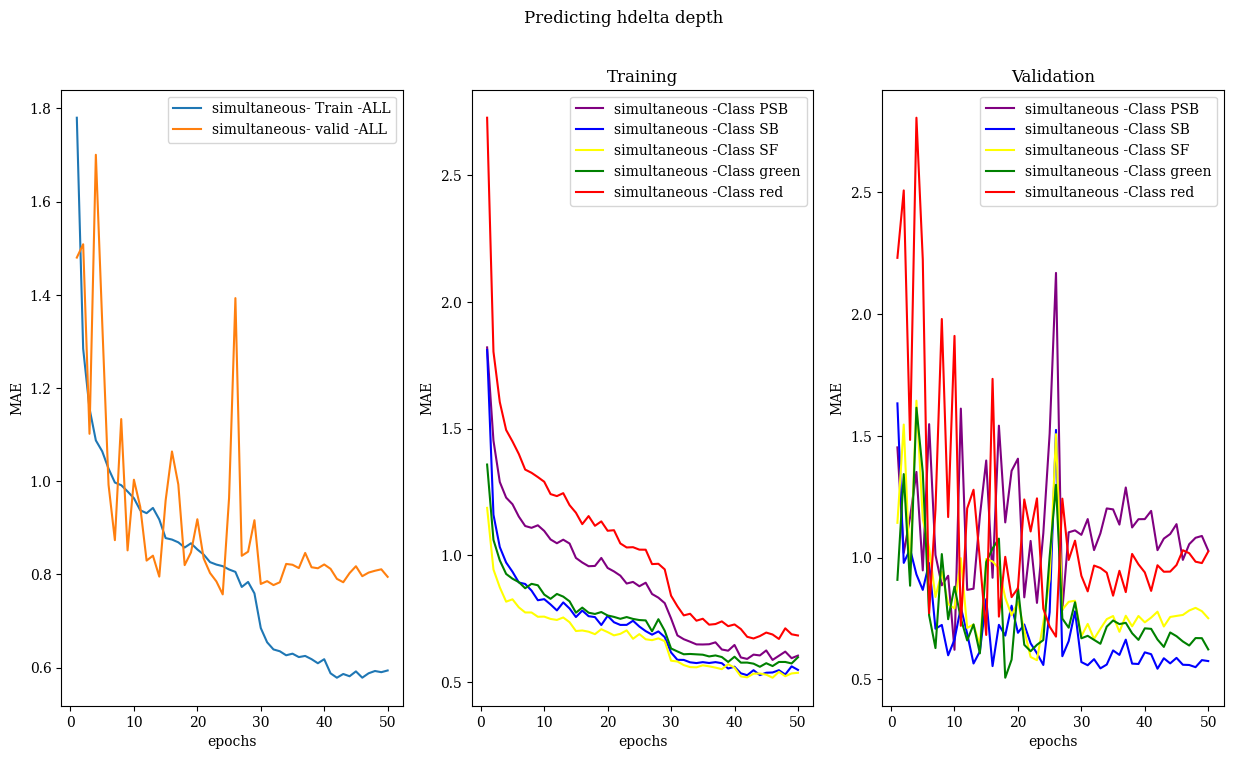

In [ ]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE[0]
M3_fgal_MAEValidLossCurve=ALLMAE[3]

M3_dn4_MAETrainLossCurve=ALLMAE[1]
M3_dn4_MAEValidLossCurve=ALLMAE[4]

M3_hdelta_MAETrainLossCurve=ALLMAE[2]
M3_hdelta_MAEValidLossCurve=ALLMAE[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

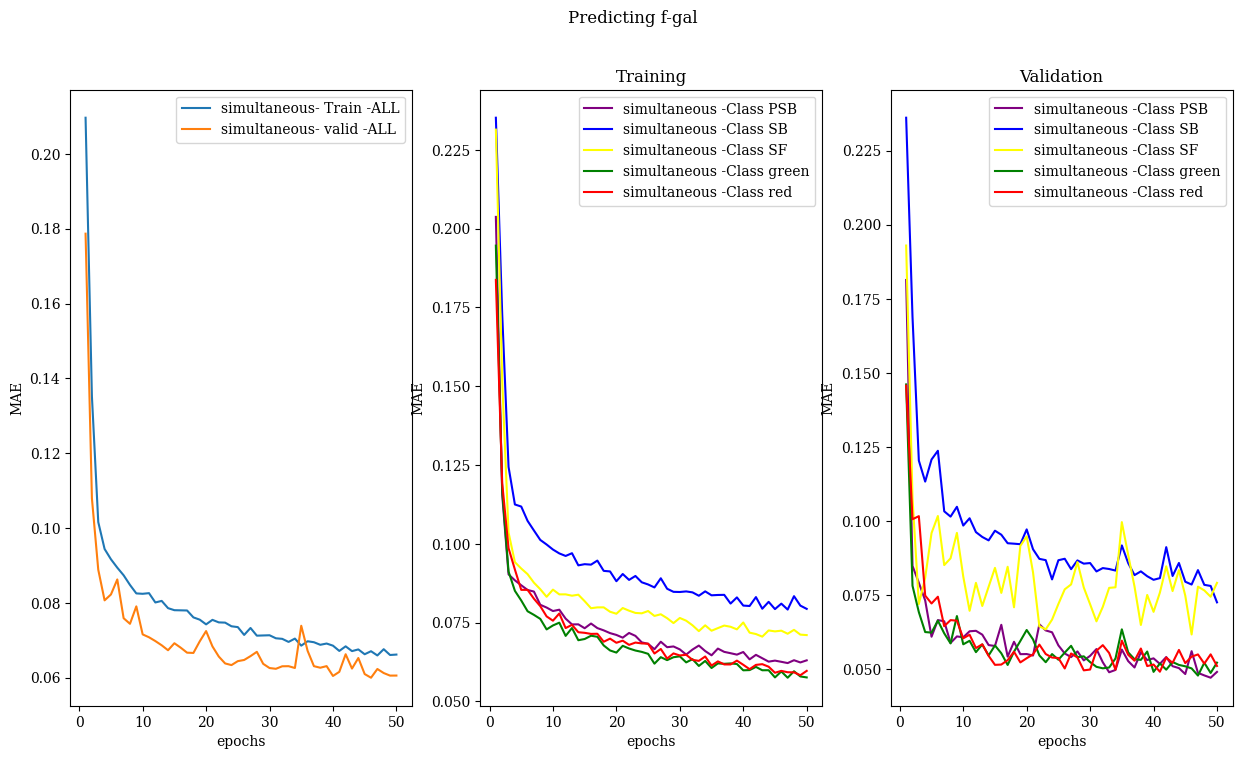

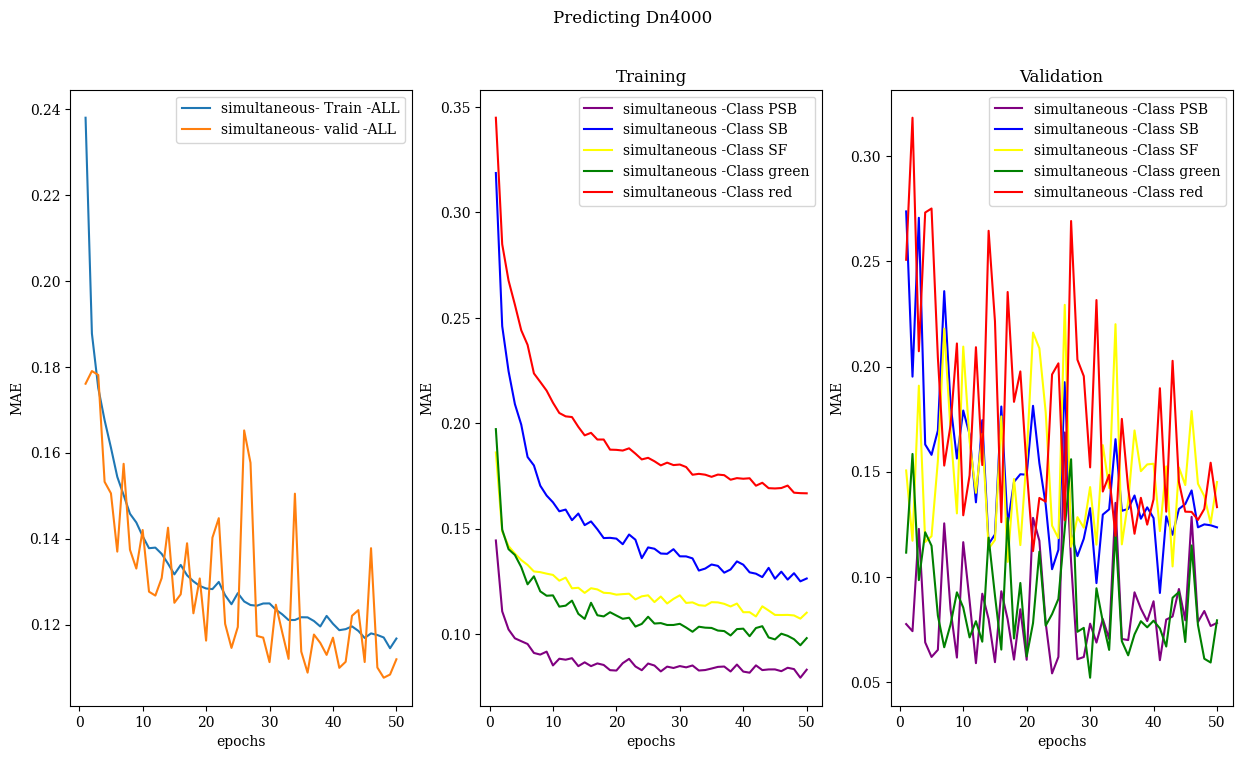

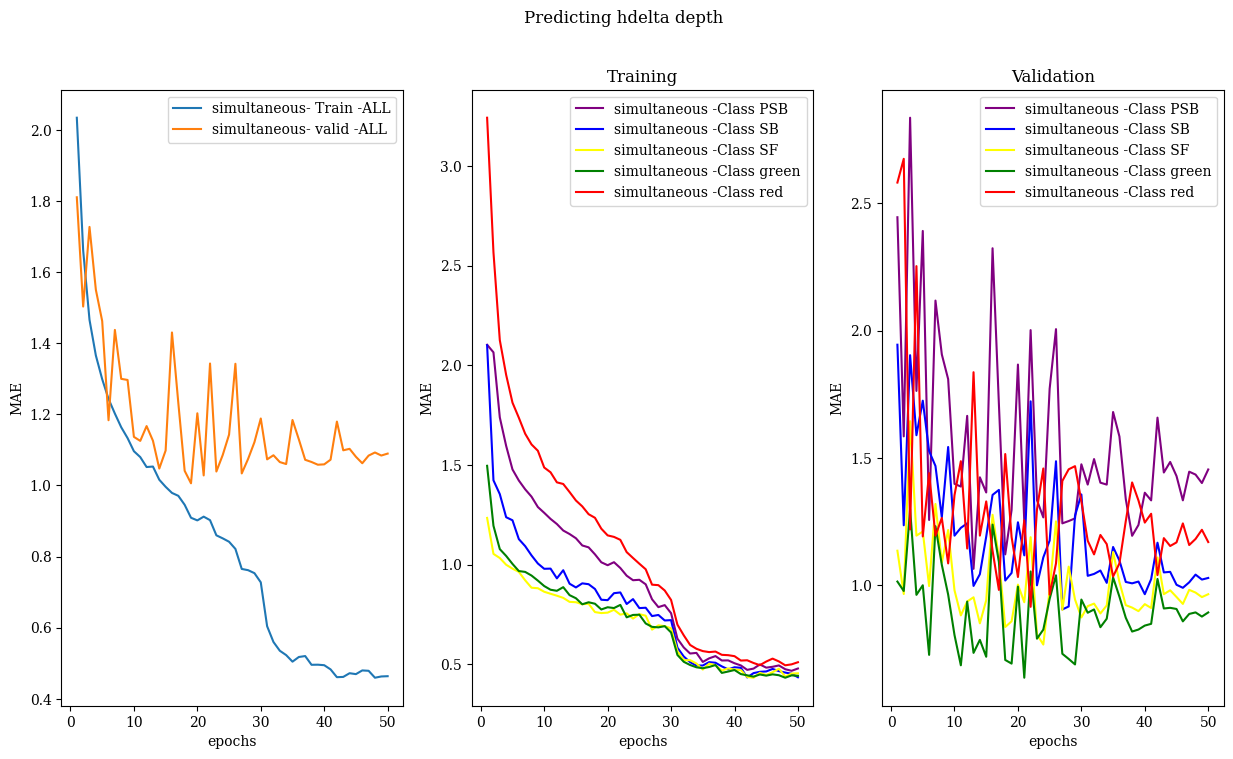

In [ ]:

fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE_RAND[0]
M3_fgal_MAEValidLossCurve=ALLMAE_RAND[3]

M3_dn4_MAETrainLossCurve=ALLMAE_RAND[1]
M3_dn4_MAEValidLossCurve=ALLMAE_RAND[4]

M3_hdelta_MAETrainLossCurve=ALLMAE_RAND[2]
M3_hdelta_MAEValidLossCurve=ALLMAE_RAND[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()